# Обнаружение радиоактивных источников в данных RADAI: от matched-фильтра к временной свёрточной сети, запечатанный локбокс и замеры на портале

**Постановка задачи.** Рассматривается обнаружение и идентификация источника гамма-излучения при проезде детектора по смоделированному городу. Используется набор данных RADAI v4.3 (ORNL/LBNL, DOE NA-22): `training_v4.3.h5` (300 прогонов с полной разметкой), `developer_v4.3.h5` и слепой `testing_v4.3.h5` (300 прогонов, метки закрыты; оценка выполняется на онлайн-портале организаторов). Качество измеряется официальными метриками: **d_recall** — доля обнаруженных встреч с источником — при заданной частоте ложных тревог **fpr** (число ложных тревог на час движения по фону).

**Результаты.** Сравниваются три детектора: физический matched-фильтр v1 («mx31»), временная свёрточная сеть c64s и её вариант s2-spd, обученный с аугментацией сжатия по времени. Интервалы в квадратных скобках — 95 %-е доверительные интервалы, полученные бутстрэпом по прогонам (run-cluster bootstrap).

*Таблица 1. Development OOF: 240 прогонов (229.4 ч фона), 5-fold кросс-валидация по прогонам. Значения d_recall при заданном fpr, 1/ч.*

| fpr, 1/ч | v1 (mx31) | c64s | s2-spd |
|---|---|---|---|
| 0.085 | 0.1199 [0.1062–0.1324] | 0.4435 [0.4199–0.4665] | **0.4481 [0.4225–0.4723]** |
| 0.17 | 0.1287 [0.1143–0.1420] | 0.4926 [0.4682–0.5150] | **0.5014 [0.4779–0.5247]** |
| 0.35 | 0.1481 [0.1332–0.1625] | 0.5347 [0.5123–0.5553] | **0.5440 [0.5183–0.5667]** |
| 0.70 | 0.1657 [0.1499–0.1812] | 0.5736 [0.5525–0.5948] | **0.5806 [0.5566–0.6019]** |

*Таблица 2. Запечатанный локбокс: 60 прогонов (57.45 ч фона), использован один раз 06.10.2026. Пороги перенесены с dev-OOF. Для выводов использовалась только цель 0.70 (основная) и 0.35 (индикативная); на целях 0.085 и 0.17 в локбоксе всего 5–13 ложных тревог, поэтому они приведены только для отчёта.*

| цель fpr, 1/ч | v1 (mx31) | c64s | s2-spd |
|---|---|---|---|
| 0.085 | 0.0981 [0.0734–0.1238] (fpr 0.087, FP 5) | 0.4519 [0.4049–0.5000] (fpr 0.104, FP 6) | 0.4407 [0.3892–0.4948] (fpr 0.139, FP 8) |
| 0.17 | 0.1130 [0.0856–0.1407] (fpr 0.174, FP 10) | 0.4870 [0.4428–0.5332] (fpr 0.139, FP 8) | 0.5000 [0.4485–0.5509] (fpr 0.226, FP 13) |
| 0.35 | 0.1389 [0.1101–0.1686] (fpr 0.296, FP 17) | 0.5278 [0.4831–0.5738] (fpr 0.296, FP 17) | 0.5519 [0.5027–0.6015] (fpr 0.453, FP 26) |
| 0.70 | 0.1593 [0.1309–0.1903] (fpr 0.714, FP 41) | 0.5722 [0.5311–0.6131] (fpr 0.696, FP 40) | 0.5833 [0.5358–0.6296] (fpr 1.010, FP 58) |

*Таблица 3. Слепой testing, официальный портал (время загрузки по часам портала). «Удержание» — отношение d_recall на testing к d_recall на dev при том же пороге.*

| замер | дата | модель | строк в файле | d_recall | fpr, 1/ч | удержание d |
|---|---|---|---|---|---|---|
| #1 `first_try` | 2026-10-02 | v1, порог 5.7492 | 413 | 0.0946 | 0.535 | 0.65 |
| #2 `second_try` | 2026-10-04 | c64s, порог 0.8617 | 727 | 0.2530 | 0.0973 | 0.570 ± 0.045 |
| #3 `third_try` | 2026-10-06 | s2-spd, порог 0.8536 | 683 | 0.2402 | 0.0730 | 0.536 [0.491–0.585] |

**Что показывают таблицы.** (1) Обе сети существенно превосходят v1: на локбоксе разность d_recall составляет +0.34…+0.42, нижние границы интервалов не ниже +0.29. (2) Различие s2-spd и c64s не обнаружено ни на dev (+0.005…+0.011), ни на локбоксе (+0.011 [−0.030; +0.050] при цели 0.70), ни на портале (−0.013, ≈1.1σ); при этом на локбоксе при цели 0.70 s2-spd сработал при фактическом fpr 1.01 против 0.70 у c64s, то есть небольшое преимущество по d_recall достигнуто за счёт большего числа ложных тревог. Две реализации одного и того же рецепта обучения (разные сиды) различаются по dev-d_recall на 0.061 при цели 0.085, поэтому разности меньше этой величины мы не считаем значимыми. (3) При переходе от dev к слепому testing d_recall сетей сохраняется примерно на 55 %, а частота ложных тревог практически не растёт (инфляция ≈ 1.2 и ≈ 0.9; у v1 было ×2.4): потери на testing связаны с пропуском слабых и быстрых встреч, а не с потоком ложных тревог. (4) Первоначальные оценки из архивного ноутбука v1 (25.2 / 40.5 / 70.0 % при 1 / 3 / 10 ложных тревогах в час) получены по более мягкому внутреннему критерию (допуск ±60 с, исключение окрестности встречи 150 с) и с официальными метриками не сопоставимы.

**Два режима.** Переключатели находятся в ячейке настройки:
- `REPRODUCE=True` (по умолчанию): все числа пересчитываются из замороженных кэшей, сохранённых предсказаний, чекпоинтов и записей замеров; время — десятки минут, GPU нужен только в §9 (пересоздание портальных CSV).
- `FULL=True`: режим пересборки (кэши §4). Обучение в этом ноутбуке **намеренно не запускается**: опубликованные веса и перегенерированные никогда не смешиваются; обучающие скрипты вынесены в `submission_v2/`.

**Данные в репозиторий не включены**: файлы `training/developer/testing_v4.3.h5` скачиваются после регистрации на BDC (условия использования — на странице набора данных). Код организаторов (`radai/`, BSD-3-Clause © UC/LBNL/ORNL 2021) не включён: используется собственная построчная реплика `submission/official_scorer.py` с сохранением атрибуции (§2 и §12). Журнал экспериментов (включая неудачные запуски) хранится в `results/logs/EXPERIMENTS.md`.

## 0. Введение: задача, данные, метод

### 0.1 Постановка задачи

Детектор, установленный на транспортном средстве, представляет собой сцинтилляционный кристалл NaI(Tl) размером 2″×4″×16″: каждый зарегистрированный гамма-квант вызывает вспышку, по которой определяются его энергия и момент регистрации. Данные представлены в формате list-mode, то есть как поток отдельных событий, а не как усреднённая скорость счёта. Транспортное средство движется по смоделированному городу из десяти кварталов с переменной скоростью и сменой полос; один прогон соответствует часовой поездке.

Городская среда сама радиоактивна: K-40 в бетоне и грунте, урановый и ториевый ряды и продукты их распада (Pb-214, Bi-214), Cs-137 в почве, космические мюоны. Этот **фон** создаёт порядка 2600 регистрируемых квантов в секунду. **Сигнал** порождается скрытым источником (в списке организаторов 24 названия: от Cs-137 и Co-60 до урановых и плутониевых материалов), мимо которого проезжает транспортное средство. Требуется выдавать тревогу при проезде мимо источника, указывать вероятный изотоп и не выдавать тревогу в его отсутствие.

Качество оценивается официальными метриками портала организаторов (подробности — в §2); в работе используются:

* **d_recall** — доля встреч с источником, обнаруженных алгоритмом;
* **c_recall** и **id_recall** — доля встреч, у которых при этом верно указаны соответственно категория (NORM, Industrial, Medical, Nuclear Material) и изотоп;
* **fpr** — число ложных тревог в час движения по фону. Это основное практическое ограничение: система, выдающая тревогу каждые пять минут, непригодна к эксплуатации. Лидерборд разбит на три таблицы по Global-fpr < 0.125, < 0.25 и < 1.0, что соответствует примерно одной ложной тревоге за 8, 4 и 1 час фона.

Трудность задачи обусловлена тем, что вариации фона от окна к окну превышают вклад источника. При смене улицы скорость счёта может вырасти в несколько раз без какого-либо источника, поэтому модель, реагирующая на превышение счёта, фактически различает участки маршрута, а не источники. Отношение сигнал/шум (**SNR**), то есть отношение числа квантов источника к стандартному отклонению флуктуаций фона, для большинства встреч составляет единицы, а вклад источника в двухсекундное окно — доли процента от полного счёта. Поэтому классификаторы, обученные на спектрах отдельных окон, показывают ROC-AUC лишь 0.53–0.65 (это исследование выполнено в архивном ноутбуке v1), тогда как значение 0.5 соответствует случайному угадыванию.

Дополнительная трудность — сдвиг распределения между обучающими и тестовыми данными, заложенный организаторами намеренно. В testing скорость движения достигает 13.4 м/с (в training — 8.0 м/с), протяжённость зон постоянной скорости больше (3–10 кварталов вместо 2–6), содержание природных радионуклидов (NORM) в фоне выше на 20 %, а часть конфигураций источников (например, Cu-67, Lu-177, ряд экранированных источников) в обучающих данных отсутствует. Следовательно, результаты на обучающем наборе не переносятся на testing автоматически, и величина этого переноса измеряется в работе отдельно (§10, §11).

### 0.2 Структура данных

Набор RADAI v4.3 ([bdc.lbl.gov](https://bdc.lbl.gov/wiki/public/radai-interactive-datasets/)) состоит из трёх файлов формата HDF5:

| файл | размер | прогоны | содержание | роль в работе |
|---|---|---|---|---|
| `training_v4.3.h5` | ≈28.6 ГБ | 300 (≈3616 с, 9.0–9.6 млн квантов каждый) | list-mode и полная разметка: источник каждого кванта, параметры встреч | обучение и валидация: 240 dev-прогонов (5-fold CV по прогонам) и 60 запечатанных прогонов локбокса (§5) |
| `developer_v4.3.h5` | ≈13.4 ГБ | короткие прогоны (≈204 с; 1950 в нашем кэше) с усиленными встречами | та же структура и разметка | предназначен организаторами для аугментации; кэш построен, но в метрики dev и локбокса не входит |
| `testing_v4.3.h5` | ≈33.4 ГБ | 300 | только `listmode/dt` и `listmode/energy`; метки и ответный ключ закрыты | слепая оценка: файл с тревогами загружается на портал организаторов |

Абсолютное время регистрации кванта в файле не хранится: для каждого кванта указан интервал `dt` до предыдущего события. Время от начала прогона восстанавливается накоплением: `t = cumsum(dt)/1e6` (с). Внутри каждого прогона training и developer данные разделены на группы:

| путь в `runs/run{i}/` | dtype | содержание |
|---|---|---|
| `listmode/dt` | uint16 | интервал от предыдущего кванта, мкс |
| `listmode/energy` | float32 | энергия кванта, кэВ (0…7000, среднее ≈324) |
| `listmode/id` | uint16 | идентификатор источника, испустившего квант; **0 — квант фона** (99.8 % всех квантов) |
| `listmode/background_id` | uint8 | для фоновых квантов — номер компоненты фона; для квантов источника совпадает с `id` |
| `sources/id` | uint16 | идентификатор источника; расшифровка — в корневом атрибуте `source_names` |
| `sources/time` | uint32 | время от начала прогона до точки наибольшего сближения (CA), мс |
| `sources/distance` | float32 | расстояние в точке наибольшего сближения, м |
| `sources/activity` | float32 | активность, Бк (от единиц до 1e8) |
| `sources/shielding` | uint16 | идентификатор экранирования (корневой атрибут `source_shielding_names`) |
| `sources/snr/{peak,integral}` | float32 | «пиковое SNR» встречи; точное определение в документации не приводится |
| `detector/position/{time,velocity,acceleration,distance}` | uint32/float32 | траектория детектора, 10 Гц; скорость в точке CA используется для разбиения встреч на терцили скорости (§7) |
| `diagnostics/*` | float32 | показатели стабильности аппаратуры, 1 Гц; не используются |

Длины массивов `listmode/*` равны числу квантов прогона, длины `sources/*` — числу источников в нём (от 5 до 13, в среднем около 9). Корневые атрибуты содержат словари имён: `source_names` (73 имени вида `Cs-137_shielding_id=2`; идентификатор 0 соответствует фону), `background_names` (8 имён: Src, K-40, U, Th, Cs137_Soil, Pb-214, Bi-214, Cosmics; у фоновых квантов `background_id` принимает значения 1–7) и `source_shielding_names`.

**Встреча (encounter)** соответствует ситуации, когда источник находится у дороги, а транспортное средство проезжает мимо: вклад источника нарастает и спадает в течение десятков секунд вокруг точки CA. Один прогон содержит от 5 до 13 встреч. Единицей учёта d_recall служит не окрестность CA фиксированной ширины, а **окно ответного ключа**, которое организаторы строят по ряду SNR: для каждой секунды вычисляется `S/√(S+B)` (S — число квантов источника, B — число квантов фона), и окном считается интервал от первой до последней секунды, где SNR превышает 5 % от пика. Для встреч training окно в среднем занимает 19.5 с (медиана 14 с, 90-й процентиль 38 с) и начинается примерно на 5 с раньше CA и заканчивается на 8 с позже. Столь узкое окно означает, что алгоритм должен указать время встречи с точностью порядка секунд, а тревога, поднятая за десятки секунд до или после пика, считается ложной.

Состав фона в `run0` по `background_id`: U-ряд ≈55 %, Th-ряд ≈28 %, K-40 ≈17 %, космическое излучение ≈0.8 %, Cs-137 в грунте ≈0.03 %. Отсюда следует принципиальная трудность: если «источником» является сам K-40 или торий (NORM-материалы), форма его спектра неотличима от фона, который из этих компонент состоит.

### 0.3 Используемые термины

* **fpr (FAR)** — число ложных тревог на час движения по фону; для testing знаменатель равен суммарной длительности прогонов за вычетом суммарной длительности окон встреч (по нашей оценке ≈ 288 ч; организаторы значение не публикуют, оценка получена целочисленной подгонкой значений лидерборда).
* **d_recall** — доля встреч, для которых найдена хотя бы одна тревога внутри окна ответного ключа. **c_recall** и **id_recall** — доли встреч, у которых при этом верны соответственно категория и изотоп.
* **Тревога** — строка файла с временем, меткой изотопа (`label_1`) и мерой уверенности (`metric_1`). Тревога внутри окна встречи — истинная; если в окно попало несколько тревог, встречу «обслуживает» тревога с наибольшим `metric_1`, остальные не штрафуются; тревога вне всех окон — ложная. Штраф за длинную тревогу равен 1 + ⌊длительность/160 с⌋, поэтому наши тревоги шириной ±2 с стоят ровно одну ложную тревогу.
* **Встреча (encounter)** — один проезд детектора мимо одного источника; **CA (closest approach)** — точка наибольшего сближения (поле `sources/time`).
* **SNR** — отношение сигнал/шум: отношение числа квантов источника к стандартному отклонению флуктуаций фона.
* **Категория** — одна из четырёх групп скоринга: NORM (K-40, Ra-226, Th-232), Industrial, Medical, Nuclear Material. По веб-документации Am-241 относится к Nuclear Material, а в коде организаторов — к Industrial; в работе используется код организаторов.
* **Пуассоновская подгонка** — подбор амплитуд заданных спектральных форм методом максимального правдоподобия в предположении пуассоновской статистики (дисперсия отсчётов равна математическому ожиданию).
* **Компонента фона** — одна из 7 типичных спектральных форм городского фона. **Шаблон (template)** — ожидаемая форма спектра конкретного изотопа в данном детекторе.
* **Matched-фильтр v1 (mx31)** — физический детектор: остаток спектра после вычитания фона проецируется на шаблоны изотопов, статистика усредняется скользящим максимумом по 62 с.
* **NORM** — природные радиоактивные материалы; **U-family** — урановые материалы (DU, LEU, NatU, RefinedU); спектры обеих групп близки к фону.
* **Dev OOF** — предсказания на 240 dev-прогонах, полученные моделью, которая этих прогонов не видела (5-fold по прогонам). **Локбокс (lockbox)** — 60 прогонов, которые не участвуют ни в обучении, ни в выборе модели и порогов и оцениваются один раз на финалистах.
* **Порог по цели fpr** — порог на `metric_1`, при котором dev-OOF даёт заданное число ложных тревог в час; цели 0.085 / 0.17 / 0.35 / 0.70 заданы до обучения.
* **Seed-шум (NF)** — разброс метрики между двумя запусками одного и того же рецепта с разными сидами; различия меньше NF считаются незначимыми.
* **Удержание (retention)** — отношение d_recall на слепом testing к d_recall на dev при том же пороге; **инфляция fpr** — отношение fpr на testing к fpr на dev.
* **Терцили скорости** — три равные по числу встреч группы по скорости платформы в точке CA (границы 4.4 и 6.8 м/с); служат реальной (не синтетической) проверкой устойчивости к быстрым проездам.
* **Бутстрэп-интервал [a–b]** — 95 %-й доверительный интервал: прогоны многократно выбираются с возвращением, метрика вычисляется заново, границами служат 2.5-й и 97.5-й процентили.

### 0.4 Близкие работы

**RADAI (ORNL/LBNL; статья набора данных, IEEE Trans. Nucl. Sci., 2026, [doi 10.1109/TNS.2026.3682654](https://doi.org/10.1109/tns.2026.3682654)).** Описывает генерацию синтетических данных, структуру наборов и онлайн-оценку. На лидерборде портала организаторы представлены бейзлайнами `baseline_nmf` и `baseline_mcew`; для ориентира, `baseline_nmf` показывает Global d_recall 0.298 при fpr 0.122 (лидерборд на 06.10.2026; значения на лидерборде могут меняться).

**Adaptive NMF (LBNL; Jones et al., [arXiv 2507.10715](https://arxiv.org/abs/2507.10715)).** Работа посвящена проблеме устаревания заранее подогнанной модели фона при попадании детектора в новую среду (другой город, осадки, радон), из-за чего частота ложных тревог дрейфует. Базис фона непрерывно пересчитывается по входящему потоку методом неотрицательной матричной факторизации; отдельный регуляризатор подавляет чувствительность модели к NORM-подобным спектральным формам, и платой за стабильность fpr становится потеря чувствительности к NORM. В настоящей работе фон в детекторе v1 фиксирован (7 компонент, определённых по 18 обучающим прогонам), а статистика проще: используется проекция остатка на шаблоны, а не совместное отношение правдоподобия гипотез «фон + источник» и «только фон».

**Waterfall-CNN (PNNL; Bachleda et al., [arXiv 2607.00270](https://arxiv.org/html/2607.00270v3)).** Цель авторов — отказаться от ручного построения физических признаков: стопка спектров во времени («водопад») подаётся в свёрточную сеть, дисбаланс классов учитывается функцией потерь Focal Loss. В настоящей работе сеть c64s принадлежит к тому же семейству (свёртки по спектрально-временному представлению, Focal Loss), но отличается входом (спектры по секундам, нормированные на медиану самого прогона, плюс четыре канала скорости счёта), временной архитектурой (dilated TCN с тремя головами: обнаружение, категория, изотоп), целью (мягкий пик вокруг CA) и протоколом: оценка выполняется официальной схемой организаторов, а модель принимается по заранее зафиксированным критериям на OOF-данных и запечатанном локбоксе.

Числа из этих работ напрямую не сопоставляются с нашими: определения fpr, границы встреч и разбиения данных у них различаются. Единственное прямое сравнение — строки лидерборда, полученные по одной и той же официальной схеме (Таблица 3 и §11).

### 0.5 Структура ноутбука

Порядок ячеек соответствует порядку исследования; каждый раздел содержит проверку, которая сверяет пересчитанные числа с сохранёнными.

| раздел | содержание |
|---|---|
| §1 | Данные и схема: размеры файлов, число прогонов, часы фона |
| §2 | Официальная схема оценки и реплика ответного ключа; проверка паритета со скорером организаторов |
| §3 | Baseline v1: физический matched-фильтр (mx31); таблицы dev-OOF |
| §4 | Декомпозиционные 1-секундные кэши (фон по компонентам, вклад источников, итоговый спектр) |
| §5 | Валидационный харнесс: замороженные сплиты, локбокс, бутстрэп |
| §6 | Обучаемая модель c64s: признаки, цели, архитектура, функция потерь |
| §7 | OOF-таблицы, терцили скорости, контроль сдвига времени, аудит утечек |
| §8 | Аугментация s2-spd (сжатие по времени) и абляция: контроль s2-0, s2-thin, s2-bg; s2-all снят до обучения по гейту реалистичности |
| §9 | Генерация CSV для портала; побайтовое воспроизведение загруженных файлов |
| §10 | Запечатанный локбокс: результаты только загружаются (использован один раз) |
| §11 | Три замера на портале и итоговые таблицы |
| §12 | Атрибуция, что оригинально, ограничения |

### Ячейка настройки

Следующая ячейка задаёт порядок импорта (сначала `torch`, из-за особенности загрузки DLL в Windows), пути относительно корня репозитория и переключатели режимов `REPRODUCE` / `FULL`. Порядок строк менять нельзя.

In [1]:
# ---- 0.0 import order: torch FIRST (Windows c10.dll fix) ----
# On this Windows env, importing numpy/pandas (MKL DLLs) before torch can crash
# the kernel with "[WinError 126] ... c10.dll"; importing torch first resolves
# the DLL load order.  Do NOT reorder this cell.
import torch

import hashlib
import json
import os
import pickle
import random
import sys
import time
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")                      # headless
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

say = lambda *a: print(" ".join(str(x) for x in a))
print(f"torch {torch.__version__} | cuda available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"gpu: {torch.cuda.get_device_name(0)}")
print(f"numpy {np.__version__} | pandas {pd.__version__} | h5py {h5py.__version__}")

# ---- 0.1 paths: repo-relative only, no absolute personal paths anywhere ----
ROOT = Path.cwd()
assert (ROOT / "submission_v2").is_dir() and (ROOT / "submission").is_dir(), \
    "run this notebook from the repository root (needs submission_v2/ and submission/)"
DATA_DIR  = ROOT                       # the three *_v4.3.h5 files live here
SUB_DIR   = ROOT / "submission_v2"
CACHE_DIR = SUB_DIR / "cache"          # big frozen caches (may be a symlink/junction)
V1_DIR    = ROOT / "submission"
MODEL_DIR = ROOT / "models"            # published finalists (fallback: frozen cache)
if not (MODEL_DIR / "c64s" / "fold0.pt").exists():
    MODEL_DIR = CACHE_DIR / "models"
OUT_DIR = ROOT / "out"
OUT_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(SUB_DIR))
sys.path.insert(0, str(V1_DIR))

def rd(p):
    """Redacted path display: repo-relative posix form, never an absolute path."""
    s = str(p).replace("\\", "/")
    r = str(ROOT).replace("\\", "/")
    return "./" + s[len(r) + 1:] if s.startswith(r) else Path(s).name

# ---- 0.2 mode switches ----
REPRODUCE = True                 # default: minutes from caches/checkpoints/records
FULL      = not REPRODUCE        # hours-scale rebuild mode (NEVER trains from here)
REGEN_PORTAL   = True            # cell 9: GPU rescore of 300 testing runs, both finalists
TER_CROSSCHECK = True            # cell 7: recompute speed terciles from raw caches
LOCKBOX_RECOMPUTE = False        # cell 10: keep False; even True only re-reads saved artifacts
for k, v in dict(REPRODUCE=REPRODUCE, FULL=FULL, REGEN_PORTAL=REGEN_PORTAL,
                 TER_CROSSCHECK=TER_CROSSCHECK,
                 LOCKBOX_RECOMPUTE=LOCKBOX_RECOMPUTE).items():
    say("mode", k, "=", v)
CHECKS = {}                      # verification evidence collected across cells
T0 = time.time()

# ---- 0.3 seeds: every downstream RNG is explicitly seeded ----
SEED = 20261003                  # frozen 2026-10-02: splits/lockbox/folds
SEED_BOOT = 7                    # bootstrap stream (v2_lib default)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED); random.seed(SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
say("repo root ok |", rd(MODEL_DIR), "|", rd(CACHE_DIR), "|", rd(OUT_DIR))

torch 2.14.0+cu126 | cuda available: True
gpu: NVIDIA GeForce RTX 3060 Laptop GPU
numpy 1.24.2 | pandas 1.5.3 | h5py 3.13.0
mode REPRODUCE = True
mode FULL = False
mode REGEN_PORTAL = True
mode TER_CROSSCHECK = True
mode LOCKBOX_RECOMPUTE = False
repo root ok | ./models | ./submission_v2/cache | ./out


## 1. Данные и схема

Подробное описание структуры файлов — в §0.2; ниже проверяются размеры, число прогонов и схема.

RADAI v4.3 — три файла с listmode-записями (dt, energy, id, background_id) на
прогон: `training_v4.3.h5` (~28.6 ГБ, 300 прогонов с полными метками),
`developer_v4.3.h5` (~13.4 ГБ), `testing_v4.3.h5` (~33.4 ГБ, слепой: только
dt/energy, метки и ответный ключ закрыты на портале). Из `training`-файла
харнесс делает 240 dev-прогонов (пул) + 60 seal-прогонов локбокса (§5).
Официальные label 24 шт. (radai `label_manager`), категории скоринга —
Medical / Industrial / NuclearMaterial / Global; NORM — фоновые встречи.
Файлы в git не лежат (BDC-регистрация); здесь читаем только attrs/схему.

In [2]:
# ---- 1.1 the three v4.3 files: size, runs, hours, schema ----
FILES = {"train": DATA_DIR / "training_v4.3.h5",
         "dev":  DATA_DIR / "developer_v4.3.h5",
         "test": DATA_DIR / "testing_v4.3.h5"}
for nm, p in FILES.items():
    assert p.exists(), f"missing {nm} data file {p.name} - download via BDC, see README"
    say(rd(p), f"{p.stat().st_size} bytes ({p.stat().st_size / 2**30:.1f} GiB)")

with h5py.File(FILES["train"], "r") as f:
    say(f"train root attrs: {sorted(f.attrs.keys())}")
    r0 = sorted(int(k[3:]) for k in f['runs'])[0]
    g = f[f"runs/run{r0}"]
    say(f"sample run{r0}: keys {sorted(g.keys())}")
    say("  listmode:", {k2: str(v.dtype) + f" n={v.shape[0]}" for k2, v in g["listmode"].items()})
    say("  sources:", {k2: (str(v.dtype) + f" n={v.shape[0]}") if isinstance(v, h5py.Dataset)
                       else "group" + str(tuple(sorted(v.keys()))[:4])
                       for k2, v in g["sources"].items()})
for nm in ("dev", "test"):
    with h5py.File(FILES[nm], "r") as f:
        runs = sorted(int(k[3:]) for k in f["runs"])
        hrs = sum(float(f[f'runs/run{r}'].attrs["end_timestamp"] -
                        f[f'runs/run{r}'].attrs["start_timestamp"]) for r in runs) / 3600
        has_id = "id" in f[f"runs/run{runs[0]}"]["listmode"]
        say(f"{nm}: {len(runs)} runs, {hrs:.1f} h | listmode id column present: {has_id}")

# ---- 1.2 official label tables (BSD-3 radai tools.py, mirrored verbatim with
#         copyright preserved inside submission/official_scorer.py) ----
import official_scorer as OS
import v2_lib as V
import radai_lib as L
say(f"official labels: {len(L.OFFICIAL_LABELS)} | categories:",
    sorted(set(map(OS.label2category, L.OFFICIAL_LABELS))))
enc_all = V.load_encounters("train")
say("train-file answer key (built in §2):", len(enc_all), "encounters over",
    enc_all.run.nunique(), "runs | per category:",
    {k: int(v) for k, v in enc_all.category.value_counts().items()})
meta = V.run_meta("train")
say(f"train meta: {len(meta)} runs | mean {np.mean([m['hr'] for m in meta.values()]):.2f} h/run")

./training_v4.3.h5 28570421610 bytes (26.6 GiB)
./developer_v4.3.h5 13448508688 bytes (12.5 GiB)
./testing_v4.3.h5 33400715077 bytes (31.1 GiB)
train root attrs: ['background_ids', 'background_names', 'format', 'source_ids', 'source_names', 'source_shielding_ids', 'source_shielding_names']
sample run0: keys ['detector', 'diagnostics', 'listmode', 'sources']
  listmode: {'background_id': 'uint8 n=9407758', 'dt': 'uint16 n=9407758', 'energy': 'float32 n=9407758', 'id': 'uint16 n=9407758'}
  sources: {'activity': 'float32 n=10', 'distance': 'float32 n=10', 'id': 'uint16 n=10', 'location_id': 'uint16 n=10', 'shielding': 'uint16 n=10', 'snr': "group('integral', 'peak')", 'standoff': 'float32 n=10', 'time': 'uint32 n=10'}
dev: 1950 runs, 110.9 h | listmode id column present: True
test: 300 runs, 301.4 h | listmode id column present: False
official labels: 24 | categories: ['Industrial', 'Medical', 'NORM', 'NuclearMaterial']
train-file answer key (built in §2): 2700 encounters over 300 runs |

## 2. Официальное скорирование и реплика ответного ключа

Правила официального скоринга (`radai/radai/evaluation/`, BSD-3-Clause ©
University of California / LBNL / ORNL 2021):
- TP: хотя бы одна тревога с `time_start ≤ t ≤ time_stop` внутри окна ответного
  ключа того же прогона; из совпавших владелец встречи — одна с максимальным
  `metric_1`, остальные «free» (ни TP, ни FP); тревога вне окон — FP;
- `FAR = FP / (Σ часов фона − Σ часов окон)` (окна не вычитаются дважды);
- окна строит `build_answerkey`: SNR-ряд `S/√(S+B)` по 1-с бинам, жадное
  обрамление вниз от пика, пока кумулятивный вклад <25 % высоты и ≥25 бинов,
  затем span >5 % от пика.

Наша реплика — `submission/official_scorer.py` (построчный mirror с file:line
ссылками; таблицы `label2category`/`label2isotope` перенесены дословно с
сохранением copyright). **Оригинальны**: обход guard-окна `cache_build.ak_window`
(официальный цикл зацикливается на «вечных» источниках — у нас clip с флагом),
инкрементальная кривая `AlarmCurve`, run-cluster bootstrap. Ответный ключ
восстановлен in-pass при сборке кэшей и побитово совпал с официальным
`build_answerkey` на всех 504 меченых прогонах (E001/E010). Ниже две проверки:
(a) паритет скореров на validation-подмножестве, (b) пересборка всех окон из
закэшированных по-секундных колонок — бит-в-бит против frozen CSV.

In [3]:
# ---- 2.1 scorer parity: harness AlarmCurve == official replica ----
import s1_eval as E
import s1_data as D
lock_runs, runs240, folds5, hi48 = D.dev_pool()          # frozen splits (module path)
lock_runs = sorted(int(r) for r in lock_runs)            # dev_pool returns a set
rset240 = set(int(r) for r in runs240)
v1_alarms = pickle.load(open(CACHE_DIR / "v1_alarms_train.pkl", "rb"))
VAL_RUNS, PTHR = list(range(25, 125)), 5.7492            # validation subset + portal thr
rows_official = [(a["run"], a["win"], float(a["time_ms"]), a["label"], float(a["metric"]))
                 for a in v1_alarms
                 if a["run"] in set(VAL_RUNS) and a["metric"] >= PTHR and a["label"]]
ak_os = OS.build_ak()                                    # official answer key (cached CSV)
tab_os, _det_os, _enc_os, _aux_os = OS.score_rows(rows_official, ak_os)
ak = V.ak_table(enc_all)
curve_v1 = V.AlarmCurve(ak, v1_alarms)                   # full-pool v1 curve
ge = np.nonzero(np.asarray(curve_v1.thr_desc) >= PTHR)[0]
row_p = int(ge[-1]) if len(ge) else -1
tab_h = curve_v1.metrics(row_p, VAL_RUNS, meta=meta)
dv = float((tab_h.d_recall - tab_os.loc[tab_h.index, "d_recall"]).abs().max())
df_ = float((tab_h.fpr - tab_os.loc[tab_h.index, "fpr_compute"]).abs().max())
say(f"val rows @ {PTHR}: {len(rows_official)} | official d {tab_os.loc['Global','d_recall']:.4f} "
    f"far {tab_os.loc['Global','fpr_compute']:.4f} | harness d {tab_h.loc['Global','d_recall']:.4f} "
    f"far {tab_h.loc['Global','fpr']:.4f}")
say("SCORER PARITY max|diff|: d", f"{dv:.2e}", "far", f"{df_:.2e}",
    "->", "PASS" if dv < 1e-12 and df_ < 1e-12 else "FAIL")
assert dv < 1e-12 and df_ < 1e-12
CHECKS["scorer_parity_maxdiff"] = max(dv, df_)

val rows @ 5.7492: 158 | official d 0.1453 far 0.2198 | harness d 0.1453 far 0.2198
SCORER PARITY max|diff|: d 0.00e+00 far 1.94e-16 -> PASS


In [4]:
# ---- 2.2 guarded answer-key windows re-replicated from cached per-second
#      count columns: bit-exact vs the frozen encounters CSV ----
import cache_build as CB
runs_s = sorted(set(int(r) for r in enc_all.run))[:40]
enc_rt = pd.read_csv(CACHE_DIR / "encounters_train.csv", float_precision="round_trip")
sub = enc_rt[enc_rt.run.isin(runs_s)]
n_bad = n_clip = 0
worst = 0.0
with h5py.File(CACHE_DIR / "train.h5", "r") as f:
    for _, e in sub.iterrows():
        g = f[f"r{int(e.run)}"]
        S_ = g[f"sec_src_{int(e.source_id)}"][:].astype(np.float64)
        B_ = g["sec_bg"][:].astype(np.float64)
        with np.errstate(invalid="ignore"):
            col = S_ / np.sqrt(S_ + B_)                  # official SNR, all energies
        t0_, t1_, tm_, pk, wb, clipped = CB.ak_window(col, int(e.cen_bin))
        exact = (t0_ / 1e3 == e.win_start_s and t1_ / 1e3 == e.win_stop_s and
                 tm_ / 1e3 == e.win_max_s and pk == float(e.snr_window))
        n_bad += not exact
        n_clip += bool(clipped)
        worst = max(worst, abs(t0_ / 1e3 - e.win_start_s), abs(pk - float(e.snr_window)))
say(f"windows re-replicated: {len(sub)} (40-run sample) | mismatches {n_bad} | "
    f"clipped-by-guard {n_clip} | max|diff| {worst:.3e}")
assert n_bad == 0
CHECKS["answerkey_replica_mismatches"] = n_bad
say("guard note: the official greedy loop never terminates for persistent sources;")
say("ak_window clips at the run tail and flags 'clipped' - our original fix (E010).")
say("parser note: float_precision='round_trip' is required - pandas' default fast")
say("float parser mis-rounds 41/382 snr_window decimals by 1-2 ULP (found in dev).")

windows re-replicated: 382 (40-run sample) | mismatches 0 | clipped-by-guard 0 | max|diff| 0.000e+00


guard note: the official greedy loop never terminates for persistent sources;
ak_window clips at the run tail and flags 'clipped' - our original fix (E010).
parser note: float_precision='round_trip' is required - pandas' default fast
float parser mis-rounds 41/382 snr_window decimals by 1-2 ULP (found in dev).


## 3. Baseline v1 — matched filter (физический детектор)

v1: пачка матчинг-фильтров по спектральным шаблонам источников поверх 1-с
биннинга (архивный ноутбук `Matched_Filter_Detection.ipynb`; портал-замер #1
`first_try` 2026-10-02: thr 5.7492 → d 0.0946, FAR 0.535/ч). В v2-харнессе v1
заморожен как reference-кривая: тревоги на всём пуле 240 сохранены
(`cache/v1_alarms_train.pkl`), пороги под FAR-цели `{0.085, 0.17, 0.35, 0.7}`/ч
и таблицы — в `reports/v1_baseline.json`. Ячейка **пересчитывает** пороги,
таблицы и bootstrap-CI и сверяет с сохранённым — ожидаем нулевую разницу
(верификация №2). Synth-shift строки baseline — загружены (их пересборка в
REPRODUCE стоит ~4 мин и относится к FULL-объёму).

In [5]:
# ---- 3. recompute v1 dev tables; diff vs saved reports/v1_baseline.json ----
base = json.loads((SUB_DIR / "reports" / "v1_baseline.json").read_text(encoding="utf-8"))
worst_all = 0.0
rowsv = {}
for tg in E.TARGETS:
    thr, row, t = curve_v1.thr_at_fpr(tg, runs240, meta=meta)
    ci_d = V.boot_at_row(curve_v1, row, runs240, meta, "d_recall", 1000)
    ci_f = V.boot_at_row(curve_v1, row, runs240, meta, "fpr", 1000)
    sv = base["dev_targets"][str(tg)]
    d1 = abs(float(thr) - float(sv["thr"]))
    d2 = max(abs(float(r[f2]) - float(rr[f2]))
             for r, rr in zip(t.reset_index().to_dict("records"), sv["table"])
             for f2 in ("n_enc", "tp", "tc", "tid", "fp", "d_recall", "c_recall",
                        "id_recall", "fpr"))
    d3 = max(float(np.max(np.abs(np.asarray(ci_d) - np.asarray(sv["ci_d"])))),
             float(np.max(np.abs(np.asarray(ci_f) - np.asarray(sv["ci_f"]))))
             if sv.get("ci_d") and sv.get("ci_f") else 0.0)
    g = t.loc["Global"]
    say(f"@{tg:<5} thr {thr:.4f} | d {g['d_recall']:.4f} [{ci_d[0]:.4f},{ci_d[1]:.4f}] "
        f"far {g['fpr']:.4f} (FP {int(g['fp'])}) | vs saved max|diff| {max(d1, d2, d3):.1e}")
    worst_all = max(worst_all, d1, d2, d3)
    rowsv[tg] = row
say("VERIFICATION #2 - v1 tables vs reports/v1_baseline.json: max|diff| =",
    f"{worst_all:.3e}")
assert worst_all == 0.0
CHECKS["v1_baseline_maxdiff"] = worst_all
thr_at = float(curve_v1.thr_desc[row_p])
_, _, tp_ = curve_v1.thr_at_fpr(0.085, runs240, meta=meta)
nenc_fit = int(round(tp_.loc["Global", "tp"] / tp_.loc["Global", "d_recall"]))
say(f"v1 OOF @.085: TP {int(tp_.loc['Global','tp'])} / N_enc {int(tp_.loc['Global','n_enc'])}"
    f" -> N_enc {nenc_fit} (used by §10)")
tp_pool = curve_v1.metrics(row_p, runs240, meta=meta)
say(f"v1 at portal thr {thr_at:.4f} on the 240 pool: d {tp_pool.loc['Global','d_recall']:.4f} "
    f"far {tp_pool.loc['Global','fpr']:.4f}")
worst_hi = 0.0
for tg in E.TARGETS:
    m2 = curve_v1.metrics(rowsv[tg], hi48, meta=meta)
    sv = next(r for r in base["high_bg"] if float(r["target"]) == tg)
    worst_hi = max(worst_hi, abs(float(m2.loc["Global", "fpr"]) - float(sv["fpr"])),
                   abs(float(m2.loc["Global", "d_recall"]) - float(sv["d"])))
say(f"high-bg shift slice vs saved baseline: max|diff(d,far)| {worst_hi:.3e}"
    " (synth-shift rows: loaded from baseline json, their re-synthesis is FULL-scope)")
assert worst_hi == 0.0

@0.085 thr 6.2266 | d 0.1199 [0.1062,0.1324] far 0.0828 (FP 19) | vs saved max|diff| 0.0e+00


@0.17  thr 5.9117 | d 0.1287 [0.1143,0.1420] far 0.1657 (FP 38) | vs saved max|diff| 0.0e+00


@0.35  thr 5.6020 | d 0.1481 [0.1332,0.1625] far 0.3488 (FP 80) | vs saved max|diff| 0.0e+00


@0.7   thr 5.2640 | d 0.1657 [0.1499,0.1812] far 0.6976 (FP 160) | vs saved max|diff| 0.0e+00
VERIFICATION #2 - v1 tables vs reports/v1_baseline.json: max|diff| = 0.000e+00
v1 OOF @.085: TP 259 / N_enc 2160 -> N_enc 2160 (used by §10)
v1 at portal thr 5.7492 on the 240 pool: d 0.1389 far 0.2441
high-bg shift slice vs saved baseline: max|diff(d,far)| 0.000e+00 (synth-shift rows: loaded from baseline json, their re-synthesis is FULL-scope)


## 4. Декомпозиционные 1-секундные кэши

`cache_build.py` за один streaming-проход по listmode строит на каждый прогон
матрицы в **официальной сетке**: 1-с бины × 128 энергетических бинов (равные по
√E в [15, 3000) keV — формула radai `read_listmode_blind`). Разложения:
`total`, фон `bg_all` + 7 компонент `bg_comp` (background_id 1..7), поинстансные
«капюшоны» источников `enc_q` (±150 с, nearest-own-instance), `src_rest`,
по-секундные `rate_all / rate_in` и официальные счётные колонки
`sec_bg / sec_src_{id}` (из них восстанавливаются SNR и ответный ключ — §2.2).
Слепой `test.h5` хранит только total/rates. Модельные сторы: `feat.h5`
(132-канальные признаки 300 прогонов training-файла — 240 пула для обучения и
60 локбокса только для инференса), `feat_test_diag.h5` (признаки 300
testing-прогонов, inference-only), `train_fix.h5` + `feat_s2-*.h5` — база
аугментации Stage-2 (E046: фиксированные по-инстансные капюшоны). Инварианты
V1/V2 перепроверяются ниже; полная пересборка (`cache_build.build`, часы) —
только в FULL, здесь не запускается.

In [6]:
# ---- 4.1 what exists on disk ----
for fn, desc in {
    "train.h5": "300 labeled runs decomposed (240 pool + 60 SEALED lockbox)",
    "dev.h5":   "developer-file runs (pre-registration sanity only)",
    "test.h5":  "300 blind testing runs (total/rate streams only)",
    "feat.h5":  "model store: 132ch features + targets, pool + lockbox",
    "feat_test_diag.h5": "model store: testing-run features (inference only)",
    "train_fix.h5": "Stage-2 decomposition, per-instance hoods fixed (E046)",
}.items():
    p = CACHE_DIR / fn
    sz = p.stat().st_size / 2**30 if p.exists() else float("nan")
    say(f"{rd(p):<40} {sz:>7.2f} GiB  {desc}")
log_tr = json.loads((CACHE_DIR / "build_log_train.json").read_text(encoding="utf-8"))
say("build_log train:", len(log_tr["per_run"]), "runs | overflow events:",
    len(log_tr["overflow"]))

# ---- 4.2 V1/V2 invariants + rate identities re-checked on 8 pool runs ----
# NOTE: cache_build stores per-instance hoods `enc_q` as COMPACT (2*W+1, 128)
# windows already zero-masked outside their CA segment (E046 layout); the full
# nb x 128 hood sum is reconstructed by placing each slice at its clipped rows.
import s1_train as S
nchk = 0
W_ = CB.W
with h5py.File(CACHE_DIR / "train.h5", "r") as f:
    for rid in list(runs240)[:8]:
        g = f[f"r{rid}"]
        nb = int(g["total"].shape[0])
        tot = g["total"][:].astype(np.int64)
        bg = g["bg_all"][:].astype(np.int64)
        comp = g["bg_comp"][:]
        rest = g["src_rest"][:].astype(np.int64)
        hood = np.zeros_like(tot)
        for e_ in enc_all[enc_all.run == rid].sort_values("inst").itertuples():
            lo = int(e_.cen_bin) - W_
            sl = g[f"enc_{int(e_.inst)}"][:].astype(np.int64)   # (2W+1, NB)
            r_lo, r_hi = max(lo, 0), min(lo + 2 * W_ + 1, nb)
            hood[r_lo:r_hi] += sl[r_lo - lo:r_hi - lo]
        ssum = g["sec_bg"][:].astype(np.int64)
        for k2 in g.keys():
            if k2.startswith("sec_src_"):
                ssum += g[k2][:].astype(np.int64)
        ok = (np.array_equal(comp.sum(0).astype(np.int64), bg)              # V2a
              and np.array_equal(bg + hood + rest, tot)                  # V2b
              and np.array_equal(ssum, g["rate_all"][:].astype(np.int64))    # V2c
              and np.array_equal(tot.sum(1), g["rate_in"][:].astype(np.int64))
              and int(comp.max()) < 65536 and int(tot.max()) < 65536)    # V1 uint16
        assert ok, f"invariant broken r{rid}"
        nchk += 1
say(f"invariants V1/V2a/V2b/V2c + rate identities: {nchk}/8 runs re-checked, all exact")
CHECKS["cache_invariants_runs"] = nchk
if FULL:
    say("FULL note: cache rebuild = cache_build.build('train'|'dev'|'test') - hours;")
    say("not executed even in FULL mode inside this notebook by default (guard above).")

./submission_v2/cache/train.h5              2.83 GiB  300 labeled runs decomposed (240 pool + 60 SEALED lockbox)
./submission_v2/cache/dev.h5                1.10 GiB  developer-file runs (pre-registration sanity only)
./submission_v2/cache/test.h5               0.27 GiB  300 blind testing runs (total/rate streams only)
./submission_v2/cache/feat.h5               0.15 GiB  model store: 132ch features + targets, pool + lockbox
./submission_v2/cache/feat_test_diag.h5     0.14 GiB  model store: testing-run features (inference only)
./submission_v2/cache/train_fix.h5          2.83 GiB  Stage-2 decomposition, per-instance hoods fixed (E046)
build_log train: 300 runs | overflow events: 0
invariants V1/V2a/V2b/V2c + rate identities: 8/8 runs re-checked, all exact


## 5. Валидационный харнесс: замороженные сплиты, локбокс, bootstrap

`harness_freeze.py` (2026-10-02, seed **20261003**, записано однократно;
существующие файлы защищены от перезаписи без `--force`): страты по фону
(квартили медианного cps) × бакеты числа встреч; **60 seal-прогонов**
(локбокс) — пропорциональный стратифицированный выбор; 240 пула → 5 складок
стратифицированным round-robin; high-bg slice — топ-20 % пула по фону.
Протокол локбокса: один-единственный осмотр после полной заморозки
модели/порога/CSV (§10). **Bootstrap** — кластерный по прогонам (B=1000,
seed 7). Синт-сдвиг для оценок (`shift_synth`) заморожен на Stage 0:
rate U(0.90,1.30), NORM ×1.20, скорость U(1.00,1.68), thinning U(0.45,0.95).
Ячейка заново **выводит** все три артефакта из seed и сверяет бит-в-бит
(без записи), прогоняет leak-guard и печатает замороженные параметры.

In [7]:
# ---- 5.1 re-derive the frozen splits from the recorded seed (verbatim
#      selection logic from harness_freeze.main, minus the writes) ----
import harness_freeze as HF
bg_s = pd.Series({p["run"]: p["cps_med"] for p in log_tr["per_run"]})
nenc = pd.Series({r: m["n_enc"] for r, m in meta.items()})
runs = np.array(sorted(meta))
key = pd.Series(HF.strata_keys(bg_s[runs], nenc[runs]), index=runs)
rng = np.random.default_rng(HF.SEED)
lock = []
groups = pd.Series(runs).groupby(key[runs].to_numpy())
for gname, ids in groups:
    ids = np.sort(np.asarray(ids))
    want = int(round(len(ids) / len(runs) * HF.N_LOCK))
    if want:
        lock.extend(sorted(rng.choice(ids, size=min(want, len(ids)), replace=False).tolist()))
if len(lock) > HF.N_LOCK:
    lock = sorted(lock)[:HF.N_LOCK]
while len(lock) < HF.N_LOCK:
    for gname, ids in sorted(groups, key=lambda kv: -len(kv[1])):
        cand = [r for r in np.sort(np.asarray(ids)) if r not in lock]
        if cand:
            lock.append(int(cand[0]))
            break
lock = sorted(lock)
dev = [r for r in runs if r not in set(lock)]
folds = [[] for _ in range(5)]
for gname, ids in groups:
    ids = np.sort(np.asarray([r for r in ids if r in set(dev)]))
    perm = rng.permutation(len(ids))
    for j, r in enumerate(ids[perm]):
        folds[j % 5].append(int(r))
folds = [sorted(fl) for fl in folds]
dev_bg = bg_s[dev].sort_values(ascending=False, kind="stable")
hi = sorted(int(r) for r in dev_bg.index[:max(1, round(0.2 * len(dev)))])
saved = {n: json.loads((CACHE_DIR / n).read_text(encoding="utf-8"))
         for n in ("lockbox.json", "folds.json", "shift_slice.json")}
ok_lb = lock == saved["lockbox.json"]["runs"]
ok_fd = folds == saved["folds.json"]["folds"]
ok_hi = hi == saved["shift_slice.json"]["high_bg_runs"]
ok_bg = all(abs(bg_s[int(rr_)] - float(bb_)) == 0 for rr_, bb_ in
            saved["shift_slice.json"]["bg_cps_dev_sorted"])
say(f"lockbox re-derived == frozen: {ok_lb} (n={len(lock)}) | folds == frozen: {ok_fd} "
    f"(sizes {[len(fl) for fl in folds]}) | high-bg == frozen: {ok_hi} (n={len(hi)}) | "
    f"bg ordering == frozen: {ok_bg}")
assert ok_lb and ok_fd and ok_hi and ok_bg
assert lock == list(lock_runs) and folds == folds5 and hi == list(hi48) and dev == list(runs240)
CHECKS["freeze_bitexact"] = "PASS"
say("strata sizes:", {k: int(v) for k, v in key.value_counts().sort_index().items()})

# ---- 5.2 leak guard + frozen shift parameters + bootstrap spec ----
D.assert_no_lockbox(dev, "notebook pool recheck", OUT_DIR / "leakguard_notebook.log")
for i, fl in enumerate(folds):
    D.assert_no_lockbox(fl, f"notebook fold{i}", OUT_DIR / "leakguard_notebook.log")
say("assert_no_lockbox: pool + 5 folds clean ->", rd(OUT_DIR / "leakguard_notebook.log"))
import shift_synth as SH
say(f"synth-shift (eval, FROZEN): rate U{SH.BG_RATE} NORM x{SH.NORM_BOOST} "
    f"speed U{SH.SPEED} thin U{SH.THIN} seed {SH.SEED}")
say(f"bootstrap: run-cluster, B=1000, seed {SEED_BOOT} (v2_lib.boot_at_row)")

lockbox re-derived == frozen: True (n=60) | folds == frozen: True (sizes [57, 49, 46, 44, 44]) | high-bg == frozen: True (n=48) | bg ordering == frozen: True
strata sizes: {'0_10-11': 20, '0_8-9': 33, '0_<=7': 14, '0_>=12': 8, '1_10-11': 32, '1_8-9': 25, '1_<=7': 16, '1_>=12': 2, '2_10-11': 32, '2_8-9': 27, '2_<=7': 13, '2_>=12': 3, '3_10-11': 32, '3_8-9': 23, '3_<=7': 12, '3_>=12': 8}
assert_no_lockbox: pool + 5 folds clean -> ./out/leakguard_notebook.log
synth-shift (eval, FROZEN): rate U(0.9, 1.3) NORM x1.2 speed U(1.0, 1.68) thin U(0.45, 0.95) seed 20261003
bootstrap: run-cluster, B=1000, seed 7 (v2_lib.boot_at_row)


## 6. Обучаемая модель (Stage-1)

**Признаки** (`s1_data.features`, 132 канала на 1-с бин): 128 —
√((total+0.5)/(робастный медианный спектр прогона+0.5)) (пуассоновская
дисперсионная стабилизация, label-free, частичная инвариантность к gain);
4 — робастные z-курса (all/in-band) и rise относительно 31-с rolling median.
Всё считается вслепую на testing. **Цели**: hard = вхождение секунды в
официальное окно (TP-правило дословно); soft = гауссов «пик» вокруг win_max
(σ=6 с, амплитуда 0.9, обрез ±12 с за окном); `tcat/tiso` — метки только на
hard-положительных секундах. **Сеть** (`s1_model.Net`): общий 2-D stem по
энергии (early pooling), проекция в 96, TCN из 4 блоков (разрежения 1-2-4-8,
ядро 5), dropout 0.05, головы det / cat(4) / iso(24). **Loss**:
focal(γ=2, α=0.75) на soft-цель + 0.5·CE_cat + 0.5·CE_iso (hard-секунды);
AdamW, cosine LR 1.5e-3, grad-clip 1.0, окна ctx=64, ранний стоп patience 3 на
inner-split val focal (правило заморожено). Конфиги: `c64s` — базовый финалист
(Stage-1); `s2-spd` — та же схема на аугментированном сторе (§8). Чекпоинты
5 складок обоих финалистов опубликованы в `models/` (10×8.83 МБ) и md5-совпадают
с замороженными копиями. **Обучение в ноутбуке не запускается ни в одном
режиме**: доказательства тренировки — чекпоинты + fold-логи. Ячейка проверяет
побитовое воспроизведение признаков/целей, архитектуру и чекпоинты.

In [8]:
# ---- 6.1 features + targets bit-exact reproduction from the 1-s caches ----
iso = D.iso_vocab()
iso2idx = {s: i for i, s in enumerate(iso)}
by_run = dict(tuple(enc_all.groupby("run")))
ctx = S.CFGS["c64s"]["ctx"]
assert len(iso) == 24
for rid, kind in ((runs240[0], "pool"), (runs240[123], "pool"), (lock_runs[0], "lockbox")):
    with h5py.File(CACHE_DIR / "train.h5", "r") as fs, h5py.File(D.FEAT_H5, "r") as ff:
        g = fs[f"r{rid}"]
        nb = int(g["total"].shape[0])
        Xc = D.features(g["total"][:], g["rate_all"][:], g["rate_in"][:])
        y, ys, tcat, tiso = D.targets(nb, by_run.get(rid, enc_all.iloc[0:0]), iso2idx)
        ok = (np.array_equal(Xc, ff[f"r{rid}/X"][:]) and np.array_equal(y, ff[f"r{rid}/y"][:])
              and np.array_equal(ys.astype(np.float16), ff[f"r{rid}/ys"][:].astype(np.float16))
              and np.array_equal(tcat, ff[f"r{rid}/tcat"][:])
              and np.array_equal(tiso, ff[f"r{rid}/tiso"][:]))
        say(f"r{rid} ({kind} feature row): features+targets vs feat.h5 bit-exact: {ok}"
            f" | X {Xc.shape} {str(Xc.dtype)}")
        assert ok
CHECKS["feat_target_bitexact"] = "PASS (3 runs; lockbox feature row layout only)"

# ---- 6.2 architecture, configs, checkpoints ----
import s1_model as M_
net = M_.Net(n_iso=len(iso))
n_par = sum(p.numel() for p in net.parameters())
say(f"Net(n_iso={len(iso)}): {n_par} params | cfg c64s: {S.CFGS['c64s']} | SEED {S.SEED}")
fold_epochs, ck = {}, {}
for cfg in ("c64s", "s2-spd"):
    hs = []
    for k in range(5):
        a = MODEL_DIR / cfg / f"fold{k}.pt"
        ha = hashlib.md5(a.read_bytes()).hexdigest()
        b = CACHE_DIR / "models" / cfg / f"fold{k}.pt"
        assert not b.exists() or ha == hashlib.md5(b.read_bytes()).hexdigest(), \
            "published ckpt differs from frozen cache ckpt"
        s_ = torch.load(a, map_location="cpu", weights_only=False)
        ck[cfg, k] = s_
        hs.append(ha[:8])
        fold_epochs.setdefault(cfg, []).append(int(s_["epoch"]))
    say(f"{cfg}: 5 fold ckpts md5 {hs} ... | identical to frozen cache copies: True |")
    say(f"   last logged epoch per fold: {fold_epochs[cfg]}")
say("ckpt keys:", sorted(ck["c64s", 0].keys()),
    "| c64s fold0 best val focal:", round(float(ck["c64s", 0]["best_val"]), 4))
assert n_par == sum(v.numel() for v in ck["c64s", 0]["best_state"].values())
for (cfg_, k_), s_ in ck.items():
    M_.Net(n_iso=len(iso)).load_state_dict(s_["best_state"])
say(f"state_dict loads clean for all {len(ck)} published checkpoints (architecture match)")
net.load_state_dict(ck["c64s", 0]["best_state"])
net.eval()
with h5py.File(D.FEAT_H5, "r") as ff:
    Xr = ff[f"r{runs240[0]}/X"][:24]
xw = torch.from_numpy(np.pad(Xr, ((ctx, ctx), (0, 0)))[None, None].astype(np.float32))
with torch.no_grad():
    dl, cl, il = net(xw, ctx)
say("forward demo (CPU, one padded window batch):", tuple(dl.shape), tuple(cl.shape),
    tuple(il.shape), f"| det logit {float(dl.ravel()[0]):.2f}")
say("leak-guard: every training/fold log under cache/models/*/leakguard.log (652 OK / 1")
say("LEAK, E055) + fresh notebook checks (§5/§7); folds are label-frozen, r%5 is a pure")
say("modulus - the 60 sealed ids never entered any training window.")
if FULL:
    say("FULL mode note: training entry point is s1_train.train_fold via s1_run.py launcher")
    say("(hours). This notebook deliberately NEVER trains in either mode - published")
    say("weights and recomputed weights must not be silently conflated.")
else:
    say("REPRODUCE: training not executed; checkpoints above are the training evidence.")

r0 (pool feature row): features+targets vs feat.h5 bit-exact: True | X (3615, 132) float16


r163 (pool feature row): features+targets vs feat.h5 bit-exact: True | X (3650, 132) float16
r3 (lockbox feature row): features+targets vs feat.h5 bit-exact: True | X (3619, 132) float16
Net(n_iso=24): 547325 params | cfg c64s: {'ctx': 64, 'target': 'soft', 'batch': 192} | SEED 20261003


c64s: 5 fold ckpts md5 ['84aca332', 'f6ad828d', '5c2b560c', '9a7ce882', 'f67ee1bb'] ... | identical to frozen cache copies: True |
   last logged epoch per fold: [8, 7, 6, 9, 5]
s2-spd: 5 fold ckpts md5 ['8abd096b', '9651e1fc', '5e456623', 'eae9a00f', '4fc6aecd'] ... | identical to frozen cache copies: True |
   last logged epoch per fold: [8, 6, 7, 7, 6]
ckpt keys: ['bad', 'best_state', 'best_val', 'cfg', 'epoch', 'model', 'opt', 'scaler', 'seed'] | c64s fold0 best val focal: 0.0358


state_dict loads clean for all 10 published checkpoints (architecture match)
forward demo (CPU, one padded window batch): (1,) (1, 4) (1, 24) | det logit 0.15
leak-guard: every training/fold log under cache/models/*/leakguard.log (652 OK / 1
LEAK, E055) + fresh notebook checks (§5/§7); folds are label-frozen, r%5 is a pure
modulus - the 60 sealed ids never entered any training window.
REPRODUCE: training not executed; checkpoints above are the training evidence.


## 7. OOF-таблицы и диагностика

Out-of-fold: прогон оценивает модель складки, **не** видевшая его (dev-OOF —
own-fold из `cache/oof/<cfg>/r*.npz`; для портал-CSV — схема r%5, §9). Ячейка
пересчитывает полные dev-OOF таблицы `c64s` и `s2-spd` из замороженных
предсказаний и сверяет с `cache/s2/metrics_<cfg>.json` (верификация №3).
Диагностики сдвига: **скоростные терцили** (первичная метрика сдвига, кромки
4.4/6.8 м/с заморожены E039; FAST — тяжёлая зона), **synth-shift**
(retention/inflation, in-band vs out-of-band), **time-shift control** (сдвиг
тревок не объясняет портал-провал, E038) и **leak-аудит** (логи гейда).

In [9]:
# ---- 7.1 OOF tables recomputed from frozen per-fold predictions ----
import s2_metrics as M2
S2J = CACHE_DIR / "s2"
sel_saved = {}
worst_all7 = 0.0
for cfg in ("c64s", "s2-spd"):
    alarms_o, curve_o, sel = M2.plain_stats(cfg, runs240, ak, meta)
    mj = json.loads((S2J / f"metrics_{cfg}.json").read_text(encoding="utf-8"))
    w = 0.0
    for tg in E.TARGETS:
        a_, b_ = sel[str(tg)], mj["sel"][str(tg)]
        w = max(w, *(abs(float(a_[f2]) - float(b_[f2]))
                     for f2 in ("thr", "d", "c", "id", "fpr", "fp")))
        w = max(w, max(abs(float(x) - float(y)) for x, y in zip(a_["ci_d"], b_["ci_d"])))
        for c_, b2 in b_["cats"].items():
            w = max(w, *(abs(float(a_["cats"][c_][f2]) - float(b2[f2]))
                         for f2 in ("d", "c", "id", "n_enc")))
    say(f"{cfg}: recomputed OOF vs saved metrics json: max|diff| {w:.1e}")
    assert w == 0.0
    worst_all7 = max(worst_all7, w)
    sel_saved[cfg] = (sel, mj, curve_o, alarms_o)
    for tg in E.TARGETS:
        r_ = sel[str(tg)]
        say(f"  @{tg:<5} thr {r_['thr']:.4f} d {r_['d']:.4f} [{r_['ci_d'][0]:.4f},"
            f"{r_['ci_d'][1]:.4f}] c {r_['c']:.4f} id {r_['id']:.4f} "
            f"far {r_['fpr']:.4f} (FP {r_['fp']:.0f})")
say("VERIFICATION #3 - OOF tables reproduce saved results: max|diff| =",
    f"{worst_all7:.3e}")
CHECKS["oof_recompute_maxdiff"] = worst_all7

def _tp_fp(rows, thr):
    """official winner-rule counts at a FIXED threshold: (n_alarms, tp_windows, fp).
    matched non-winner alarms are FREE (neither TP nor FP) - TP = distinct hit windows."""
    n = fp = 0
    hit = set()
    for rr_, t_, l_, m_ in rows:
        if m_ < thr:
            continue
        n += 1
        w = next(((s_, e_) for s_, e_ in AKD.get(int(rr_), []) if s_ <= t_ <= e_), None)
        if w is None:
            fp += 1
        else:
            hit.add((int(rr_), w))
    return n, len(hit), fp

def _dev_rows(cfg):
    return [(a["run"], int(a["time_ms"]), a["label"], float(a["metric"]))
            for a in sel_saved[cfg][3] if a["run"] in rset240]

def _dev_tp(thr):
    return {cfg: _tp_fp(_dev_rows(cfg), thr) for cfg in ("c64s", "s2-spd")}
AKD = {int(r): v[["start_ms", "stop_ms"]].drop_duplicates().values.tolist()
       for r, v in ak.groupby("run")}
NENC = sum(len(v) for r, v in AKD.items() if r in rset240)   # distinct scored windows on pool

c64s: recomputed OOF vs saved metrics json: max|diff| 0.0e+00
  @0.085 thr 0.8617 d 0.4435 [0.4199,0.4665] c 0.4273 id 0.2880 far 0.0828 (FP 19)
  @0.17  thr 0.8449 d 0.4926 [0.4682,0.5150] c 0.4750 id 0.3171 far 0.1657 (FP 38)
  @0.35  thr 0.8234 d 0.5347 [0.5123,0.5553] c 0.5157 id 0.3421 far 0.3488 (FP 80)
  @0.7   thr 0.7961 d 0.5736 [0.5525,0.5948] c 0.5509 id 0.3676 far 0.6976 (FP 160)


s2-spd: recomputed OOF vs saved metrics json: max|diff| 0.0e+00
  @0.085 thr 0.8536 d 0.4481 [0.4225,0.4723] c 0.4319 id 0.2972 far 0.0828 (FP 19)
  @0.17  thr 0.8313 d 0.5014 [0.4779,0.5247] c 0.4838 id 0.3333 far 0.1657 (FP 38)
  @0.35  thr 0.8045 d 0.5440 [0.5183,0.5667] c 0.5213 id 0.3588 far 0.3488 (FP 80)
  @0.7   thr 0.7797 d 0.5806 [0.5566,0.6019] c 0.5546 id 0.3806 far 0.6976 (FP 160)
VERIFICATION #3 - OOF tables reproduce saved results: max|diff| = 0.000e+00


In [10]:
# ---- 7.2 speed terciles (saved; TER_CROSSCHECK recomputes from raw caches) ----
for cfg in ("c64s", "s2-spd"):
    sel, mj, *_ = sel_saved[cfg]
    tc = mj["terciles"]
    if TER_CROSSCHECK:
        tc2 = M2.speed_terciles(cfg, runs240, ak, meta, sel)
        w = max(abs(float(tc2["ter"][gi]["d"][tg]) - float(tc["ter"][str(gi)]["d"][tg]))
                for gi in range(3) for tg in ("0.085", "0.17", "0.35", "0.7"))
        w = max(w, abs(float(tc2["fast_mean"]) - float(tc["fast_mean"])))
        assert w == 0.0, f"{cfg} terciles differ"
        note = "recomputed-identical"
    else:
        note = "loaded"
    say(f"{cfg} ({note}): edges {tc['edges']} | " +
        " | ".join(f"T{gi} n={tc['ter'][str(gi)]['n']} d@.085 {tc['ter'][str(gi)]['d']['0.085']:.4f}"
                   for gi in range(3)) + f" | FAST mean {tc['fast_mean']:.4f}")
    sc, so = mj["synth_cal"][0], mj["synth_out"][0]
    say(f"   synth-shift @.085: in-domain-calibrated ret {sc['retention']:.2f} "
        f"infl {sc['inflation']:.2f} | out-of-band ret {so['retention']:.2f} "
        f"infl {so['inflation']:.2f}")
CHECKS["terciles_crosscheck"] = "PASS" if TER_CROSSCHECK else "loaded"

# ---- 7.3 time-shift control + leakage audit (saved evidence) ----
ts = (SUB_DIR / "reports" / "c64s_diag.md").read_text(encoding="utf-8").splitlines()
say("time-shift control (c64s OOF, check-1, E038): first table rows")
for ln in ts[:13]:
    if ln.strip():
        say(" |", ln[:112])
say("conclusion: pure timing shift does NOT explain the portal gap; the loss is")
say("missed weak encounters + FAST-band physics (§11), not alarm misalignment.")
tot_c = tot_l = 0
for lg in sorted((CACHE_DIR / "models").rglob("leakguard.log")):
    lines = lg.read_text(encoding="utf-8").splitlines()
    tot_c += len(lines)
    tot_l += sum(1 for x in lines if "LEAK" in x and "lockbox-overlap=0" not in x)
say(f"leakguard: {tot_c} OK checks / {tot_l} LEAK across all cfg fold logs "
    f"(1 flagged event was a log-format false positive, resolved E055)")
CHECKS["leakguard_lines"] = tot_c

c64s (recomputed-identical): edges [4.4, 6.8] | T0 n=715 d@.085 0.5622 | T1 n=724 d@.085 0.4448 | T2 n=721 d@.085 0.3245 | FAST mean 0.3953
   synth-shift @.085: in-domain-calibrated ret 0.35 infl 4.32 | out-of-band ret 0.32 infl 4.32


s2-spd (recomputed-identical): edges [4.4, 6.8] | T0 n=715 d@.085 0.5636 | T1 n=724 d@.085 0.4213 | T2 n=721 d@.085 0.3606 | FAST mean 0.4303
   synth-shift @.085: in-domain-calibrated ret 0.31 infl 0.47 | out-of-band ret 0.27 infl 0.37
time-shift control (c64s OOF, check-1, E038): first table rows
 | # check 1 time-shift control -- c64s
 | policy: shifted alarms landing outside [0, nb_s) of their own run are DROPPED (no wrap); scores unchanged; thres
 | | shift | target | thr | d_G | c_G | id_G | fpr | FP |
 | |---|---|---|---|---|---|---|---|
 | | +0s | 0.085 | 0.8617 | 0.4435 | 0.4273 | 0.2880 | 0.0828 | 19 |
 | | +0s | 0.17 | 0.8449 | 0.4926 | 0.4750 | 0.3171 | 0.1657 | 38 |
 | | +0s | 0.35 | 0.8234 | 0.5347 | 0.5157 | 0.3421 | 0.3488 | 80 |
 | | +0s | 0.7 | 0.7961 | 0.5736 | 0.5509 | 0.3676 | 0.6976 | 160 |
 | | +400s | 0.085 | 0.8617 | 0.0181 | 0.0079 | 0.0014 | 3.9150 | 898 |
 | | +400s | 0.17 | 0.8449 | 0.0208 | 0.0102 | 0.0023 | 4.4469 | 1020 |
 | | +400s | 0.35 | 0.8234 | 0.0

## 8. Аугментация s2-spd (speed-compression) и абляция

Гипотеза: портал «сдвигает» встречи к более быстрым/слабым (d-удержание
dev→portal ≈0.56). Тренировочная аугментация имитирует сдвиг на капюшонах
источников: сжатие профиля вокруг CA с коэффициентом κ ~ U(1, κ_max=1.7)
(дизайн-кап; Step-0 выбрал калибровочный κ и θ для eval-транзформы, `calib.json`)
для случайных встреч (Bernoulli p=0.5) + перестройка окон ответного ключа на
аугментированных SNR-рядах через тот же guarded `ak_window` (E010). Жёсткие
гейты перед обучением: **T1** — identity fast path побитово воспроизводит
feat-стор; **T1b** — пересборка окон при no-op аугментации побитова; **T2** —
инварианты J1–J4 + y == официальное TP-правило на перестроенных окнах;
**G1–G3** — статистические гейты (FP-rate по категориям, ширины окон, темп).
Все гейты пройдены 2026-10-06 (evidence ниже). 4 s2-конфига обучены; отбор —
**pre-registered rule**: максимум среднего FAST-терцильного d. Абляция и отбор
в этой ячейке — только из сохранённых результатов, переобучения нет.

In [11]:
# ---- 8.1 augmentation transform demo (illustrative, deterministic rng) ----
import s2_cfg as C2
import s2_aug as A
S2J.mkdir(exist_ok=True)
rid = max((r for r in runs240 if r in by_run), key=lambda r_: len(by_run[r_]))
rows_e = by_run[rid]
rng = np.random.default_rng(C2.SEED_AUG + rid)
with h5py.File(C2.TRAIN_FIX, "r") as f:
    a = A.load_run(f, rid)
out_, rows2, stats, inv = A.augment_run(a, rows_e, rng, spd=(C2.KAPPA_MAX_AUG,), p_spd=1.0)
rows_e = rows_e.iloc[:len(rows2)]                # clipped tail (run-end windows)
w0 = float((rows_e.win_stop_s - rows_e.win_start_s).mean())
w1 = float((rows2.win_stop_s - rows2.win_start_s).mean())
say(f"demo run {rid} ({len(rows2)} encounters; p_spd=1 to force visible compression -")
say(f"frozen training stores used p_spd={C2.P_SPD}): mean window width {w0:.1f}s -> {w1:.1f}s")
say(f"  n_spd={stats['n_spd']} of {len(rows2)} | k={[round(float(k_), 2) for k_ in stats['k'][:12]]}"
    f" ... | invariants {inv}")
assert all(inv.values())

# ---- 8.2 calibration + gates (saved evidence) ----
cal = json.loads((S2J / "calib.json").read_text(encoding="utf-8"))
say(f"Step-0 calibration: kappa_max {cal['kappa_max']}, theta {cal['theta']} "
    f"(source {cal['source']}, at thr {cal['thr']}; targets ret "
    f"{cal['target_retention']}, infl {cal['target_inflation']})")
bs = json.loads((S2J / "build_s2-spd.json").read_text(encoding="utf-8"))
say(f"T2 build stats (s2-spd store): {len(bs['runs'])} runs, inv_fail = {bs['inv_fail']} "
    f"(J1-J4 across every augmented run) | rebuilt windows {bs['win_total']}, "
    f"changed {bs['win_changed']} | spec {bs['spec']}")
assert bs["inv_fail"] == 0
for cfg in ("s2-0", "s2-spd"):
    gj = json.loads((S2J / f"gates_{cfg}.json").read_text(encoding="utf-8"))
    say(f"gates {cfg}: subset {len(gj['subset'])} runs, {gj['n_runs']} audited | "
        f"pass G1/G2/G3 = {gj['pass_G1']}/{gj['pass_G2']}/{gj['pass_G3']} | "
        f"note: T1/T1b/T2 bit-exact gates at build time (EXPERIMENTS E046-E052)")
    g2d = gj["g2"]
    say(f"   G2 window stats: width {g2d['width']}, start_ca {g2d['start_ca']}, "
        f"stop_ca {g2d['stop_ca']}, rate_all {g2d['rate_all']:.6f}, fails {g2d['fails']}")
    say(f"   G3 notes: {gj['g3_notes'] if gj['g3_notes'] else 'none'}")
    for ti in sorted(gj["g1"], key=float):
        e_ = gj["g1"][ti]
        say(f"   G1 tgt {ti}: per-day FP-rate real {e_['pd_real']:.4f} vs aug "
            f"{e_['pd_aug']:.4f} diff {e_['diff']:+.4f} CI {e_['ci95']} "
            f"(|diff| limit {e_.get('limit', 'see gate spec')})")

# ---- 8.3 ablation table from saved metrics + pre-registered selection ----
say("config        | d@.085   d@.17   d@.35   d@.70 | FASTmean | calib-ret@.085")
for cfg in ("c64s", "s2-0", "s2-bg", "s2-thin", "s2-spd", "s2-all"):
    p = S2J / f"metrics_{cfg}.json"
    if not p.exists():
        say(f"{cfg:<12} | (not trained: dropped after Step-0 screen / budget)")
        continue
    mj = json.loads(p.read_text(encoding="utf-8"))
    ds = [float(mj["sel"][str(t)]["d"]) for t in E.TARGETS]
    say(f"{cfg:<12} | " + "  ".join(f"{d:.4f}" for d in ds) +
        f" |   {mj['terciles']['fast_mean']:.4f}  |  {mj['synth_cal'][0]['retention']:.3f}")
cf = json.loads((S2J / "compare.json").read_text(encoding="utf-8"))
say("seed-noise floor (same-data retrain noise, s2-0 vs c64s):",
    {k: round(float(v), 4) for k, v in cf["nf"].items()})
for pair in ("s2-spd_vs_c64s", "s2-spd_vs_s2-0", "s2-thin_vs_c64s", "s2-bg_vs_c64s"):
    if pair in cf["pairs"]:
        pr = cf["pairs"][pair]
        say(f"{pair}: " + " ".join(
            f"@{t}: d{float(pr[t]['diff']):+.4f} CI[{float(pr[t]['ci'][0]):+.4f},"
            f"{float(pr[t]['ci'][1]):+.4f}]" for t in ("0.085", "0.17", "0.35", "0.7")))
sj = json.loads((S2J / "selection.json").read_text(encoding="utf-8"))
say(f"PRE-REGISTERED SELECTION -> {sj['selected']} | rule: {sj['rationale']}")
CHECKS["selection_frozen"] = str(sj["selected"])

demo run 255 (14 encounters; p_spd=1 to force visible compression -
frozen training stores used p_spd=0.5): mean window width 17.2s -> 13.3s
  n_spd=14 of 14 | k=[1.43, 1.09, 1.41, 1.44, 1.63, 1.21, 1.2, 1.35, 1.14, 1.31, 1.34, 1.49] ... | invariants {'J1': True, 'J2': True, 'J3': True, 'J4': True}
Step-0 calibration: kappa_max 1.3, theta 1.0 (source fallback-nearest, at thr 0.8617; targets ret [0.52, 0.62], infl [0.8, 1.6])
T2 build stats (s2-spd store): 240 runs, inv_fail = 0 (J1-J4 across every augmented run) | rebuilt windows 2160, changed 1013 | spec {'spd': ['1.7']}
gates s2-0: subset 58 runs, 58 audited | pass G1/G2/G3 = True/True/True | note: T1/T1b/T2 bit-exact gates at build time (EXPERIMENTS E046-E052)
   G2 window stats: width 1.0, start_ca 1.0, stop_ca 1.0, rate_all 1.000000, fails []
   G3 notes: none
   G1 tgt 0: per-day FP-rate real 0.2527 vs aug 0.2527 diff +0.0000 CI [0.0, 0.0] (|diff| limit see gate spec)
   G1 tgt 1: per-day FP-rate real 0.0385 vs aug 0.0385 diff +0

## 9. Генерация портал-CSV (uploaded measurements #2/#3)

Схема **(a)**: прогон r скорится ОДНОЙ складочной моделью `r % 5`
(`best_state`, eval-режим; соответствие проверено по frozen
`measurement_assignment.txt`, §1.3). Признаки testing — из
`feat_test_diag.h5` (слепой count-стрим; testing-метки не использовались
никогда). Пороги — собственные dev-OOF порога цели FAR 0.085/ч, закреплённые до
любого testing-скоринга и округлённые до 4 знаков: `c64s 0.8617` (замер #2,
2026-10-05) и `s2-spd 0.8536` (замер #3, 2026-10-06). Извлечение тревог
заморожено: сглаживание σ=1.5 с, NMS 15 с, PMIN 0.02, ≤300/прогон; формат
строк — `submission/csv_format.py` (кавычка в заголовке `"#"`, span ±2 с, 6
знаков метрики). Ячейка **заново скорит все 300 testing-прогонов на GPU** и
пересоздаёт оба файла в `out/`; байтовая идентичность загруженным CSV —
верификация №4. Никакие промежуточные scores не сохраняются: §10 работает
только с замороженными артефактами из `reports/` (использовано один раз —
переоценка seal-прогонов запрещена протоколом). `REGEN_PORTAL=False` — только
md5-сверка сохранённых файлов без GPU.

In [12]:
# ---- 9.1 byte-for-byte regeneration of both uploaded portal CSVs ----
from csv_format import HEADER, format_row
from s1_diag import test_store, test_hours
CANON = {"c64s": "submission_v2_c64s_a_thr0p8617.csv",
         "s2-spd": "submission_v2_s2-spd_a_thr0p8536.csv"}

def canonical_path(name):
    for d in (SUB_DIR, ROOT / "results" / "portal_csv"):      # survives Phase-B move
        p = d / name
        if p.exists():
            return p
    raise FileNotFoundError("canonical portal CSV missing")

thr_c = {cfg: round(float(sel_saved[cfg][0]["0.085"]["thr"]), 4) for cfg in CANON}
say("frozen dev-OOF .085 thresholds (4dp):", thr_c)
assert thr_c == {"c64s": 0.8617, "s2-spd": 0.8536}
canon_md5 = {}
for cfg, name in CANON.items():
    cp = canonical_path(name)
    canon_md5[cfg] = hashlib.md5(cp.read_bytes()).hexdigest()
    say(f"canonical {cfg}: {rd(cp)} rows="
        f"{sum(1 for _ in open(cp, encoding='utf-8')) - 1} md5 {canon_md5[cfg][:16]}...")
model_of = {}
for line in (SUB_DIR / "reports" / "measurement_assignment.txt").read_text().splitlines()[1:]:
    r_, m_ = line.split(",")
    model_of[int(r_)] = int(m_)

if REGEN_PORTAL:
    assert torch.cuda.is_available(), "cell 9 portal regen needs the CUDA GPU"
    dev = torch.device("cuda")
    with h5py.File(V.CACHE_H5["test"], "r") as f:
        runs_t = sorted(int(k[1:]) for k in f)
    say(f"testing runs: {len(runs_t)} (ids 0..{max(runs_t)})")
    hrs = test_hours(runs_t)
    run_len = {r: int(hrs[r][0]) * 1000 for r in runs_t}       # per-second grid end, ms
    t0 = time.time()
    st, dmap = test_store(runs_t, ctx, dev)
    say(f"padded testing store on GPU: {sum(int(v) for v in st.nb.values())} windows "
        f"({time.time()-t0:.0f}s)")

    def regen(cfg, thr4):
        # --- verbatim shape of the proven s2_make_measurement.pass_alarms() ---
        t0 = time.time()
        models = {}
        for k in range(5):
            m = M_.Net(n_iso=len(iso)).to(dev)
            m.load_state_dict(ck[cfg, k]["best_state"])
            m.eval()
            models[k] = m
        al = []
        with torch.no_grad():
            for r in runs_t:                                   # scheme (a): r % 5
                mm = models[model_of[r]]
                jp = np.arange(int(st.j0[r]) + ctx, int(st.j0[r]) + ctx + int(st.nb[r]))
                acc = np.zeros(len(jp))
                acci = np.zeros((len(jp), len(iso)))
                for i in range(0, len(jp), 256):
                    j = torch.from_numpy(jp[i:i + 256]).to(dev)
                    with torch.autocast("cuda", dtype=torch.float16):
                        dl, _, il = mm(S.windows(st, j), ctx)
                    acc[i:i + 256] += torch.sigmoid(dl).float().cpu().numpy()
                    acci[i:i + 256] += il.float().cpu().numpy()
                al += [(a["run"], int(a["time_ms"]), a["label"], float(a["metric"]))
                       for a in E.alarms_from_run(
                           r, acc, (acci / 5.0).argmax(1).astype(np.int8), iso)]
        rows = sorted([x for x in al if x[3] >= thr4], key=lambda x: (x[0], x[1]))
        dst = OUT_DIR / f"portal_regen_{cfg}_thr{str(thr4).replace('.', 'p')}.csv"
        with open(dst, "w", newline="", encoding="utf-8") as fh:
            fh.write(HEADER + "\n")
            for i, (rr_, tm_, lab_, met_) in enumerate(rows):
                fh.write(format_row(i + 1, rr_, tm_, lab_, met_, run_len[rr_]) + "\n")
        h_new = hashlib.md5(dst.read_bytes()).hexdigest()
        say(f"{cfg} thr {thr4}: rows {len(rows)} -> {rd(dst)} | md5 {h_new[:16]}... | "
            f"canonical {canon_md5[cfg][:16]}... | BYTE-EQUAL: {h_new == canon_md5[cfg]} "
            f"({time.time()-t0:.0f}s)")
        assert h_new == canon_md5[cfg], "regenerated CSV != uploaded bytes"
        del models
        torch.cuda.empty_cache()
        return len(rows)

    n2 = regen("c64s", thr_c["c64s"])
    n3 = regen("s2-spd", thr_c["s2-spd"])
    assert n2 == 727 and n3 == 683
    CHECKS["portal_regen_md5"] = "EQUAL both files (727 / 683 rows)"
    CHECKS["portal_regen_rows"] = (n2, n3)
else:
    CHECKS["portal_regen_md5"] = "flag off - md5 of stored files only"
say("VERIFICATION #4 - regenerated CSVs byte-identical to uploaded files:",
    CHECKS["portal_regen_md5"])

frozen dev-OOF .085 thresholds (4dp): {'c64s': 0.8617, 's2-spd': 0.8536}
canonical c64s: ./submission_v2/submission_v2_c64s_a_thr0p8617.csv rows=727 md5 e41c68e31905223e...
canonical s2-spd: ./submission_v2/submission_v2_s2-spd_a_thr0p8536.csv rows=683 md5 c04e558df82940c3...
testing runs: 300 (ids 0..299)


padded testing store on GPU: 1084864 windows (3s)


c64s thr 0.8617: rows 727 -> ./out/portal_regen_c64s_thr0p8617.csv | md5 e41c68e31905223e... | canonical e41c68e31905223e... | BYTE-EQUAL: True (330s)


s2-spd thr 0.8536: rows 683 -> ./out/portal_regen_s2-spd_thr0p8536.csv | md5 c04e558df82940c3... | canonical c04e558df82940c3... | BYTE-EQUAL: True (335s)
VERIFICATION #4 - regenerated CSVs byte-identical to uploaded files: EQUAL both files (727 / 683 rows)


## 10. Seal-локбокс: результаты ТОЛЬКО загружаются (использован один раз)

**Локбокс использован один раз 2026-10-06** после полной заморозки (модели,
порога, CSV, текстов). Правила (frozen в `LOCKBOX_LOG.md`): осмотр только
финалистов + v1 reference; порог FAR 0.70/ч — первичная точка (power-анализ:
~45 ожидаемых FP), 0.35 — secondary, 0.085/0.17 — report-only; отбор/тюнинг по
локбоксу запрещён и не проводился. Скрипт вскрытия репетировался на dev-пуле с
бит-идентичностью формул; патч харнесса задокументирован (sha 9F21EE8B…).
Ячейка **читает сохранённые артефакты** (`reports/lockbox/*`): таблицы, CI,
FP-прогоны (пересчёт из сохранённых pkl-тревог — без доступа к seal-данным).
`LOCKBOX_RECOMPUTE=True` добавляет только аналитическую сверку из сохранённых
raw-артефактов (seal-h5 не читается никогда) — по умолчанию **False**.

In [13]:
# ---- 10.1 load the three frozen lockbox reports ----
LB = SUB_DIR / "reports" / "lockbox"
BG60 = V.denom_hours(meta, sorted(lock_runs))     # fpr denominator: raw hours minus window hours
say("used once on 2026-10-06 | pool: 60 sealed runs | this cell reads saved artifacts only")
res = {}
for cfg in ("v1", "c64s", "s2-spd"):
    js = json.loads((LB / cfg / f"lockbox_{cfg}.json").read_text(encoding="utf-8"))
    res[cfg] = js
    say(f"{cfg}: n {js['n_runs']} runs | total run hours {js['bg_hours']:.2f} h | "
        f"fpr denominator V.denom_hours(lock60) = {BG60:.4f} h")
    for r_ in js["rows"]:
        ex = "" if "v1_d" not in r_ else (
            f" | vs v1: {float(r_['d_minus_v1']):+.4f} CI[{float(r_['diff_ci'][0]):+.4f},"
            f"{float(r_['diff_ci'][1]):+.4f}]")
        say(f"  @{r_['target']:<5} [{r_['role']:11}] thr {float(r_['thr']):.4f} "
            f"d {float(r_['d']):.4f} CI[{float(r_['ci_d'][0]):.4f},{float(r_['ci_d'][1]):.4f}] "
            f"c {float(r_['c']):.4f} id {float(r_['id']):.4f} far {float(r_['fpr']):.4f} "
            f"FP {int(r_['fp'])}{ex}")

# ---- 10.2 FP runs recomputed analytically from SAVED raw alarms (no sealed reads) ----
for cfg in ("v1", "c64s", "s2-spd"):
    al0 = pickle.load(open(LB / cfg / f"{cfg}_alarms.pkl", "rb"))
    row70 = next(r_ for r_ in res[cfg]["rows"] if r_["target"] == 0.7)
    al = [(a["run"], int(a["time_ms"]), a["label"], float(a["metric"])) for a in al0]
    fp = [(r_, t_) for r_, t_, l_, m_ in al if m_ >= float(row70["thr"])
          and not any(s_ <= t_ <= e_ for s_, e_ in AKD.get(int(r_), []))]
    fp_runs = sorted({r_ for r_, _ in fp})
    assert len(fp) == int(row70["fp"]), f"{cfg} FP count mismatch"
    say(f"{cfg} @0.70: {len(fp)} FP in runs {fp_runs} == saved table")
    CHECKS["lockbox_fp_recompute"] = "PASS (3/3)"

fin = json.loads((SUB_DIR / "reports" / "lockbox_final.json").read_text(encoding="utf-8"))
say("bootstrap pairs @ targets:")
for pr in fin["pairs"]:
    say(f"  {pr['pair']} @{pr['target']}: d {float(pr['d_recall']['diff']):+.4f} "
        f"CI[{float(pr['d_recall']['ci'][0]):+.4f},{float(pr['d_recall']['ci'][1]):+.4f}] | "
        f"far {float(pr['fpr']['diff']):+.4f} CI[{float(pr['fpr']['ci'][0]):+.4f},"
        f"{float(pr['fpr']['ci'][1]):+.4f}]")
for cfg, tgmap in fin["dev_vs_lockbox"].items():
    mx = max(abs(float(v["delta"])) for v in tgmap.values())
    say(f"dev->lockbox max d delta {mx:.4f} ({cfg}) - no winner's-curse signature")
tm = {c: round(float(fin["terciles"][c]["ter"]["2"]["d"]["0.7"]), 4) for c in fin["terciles"]}
say("lockbox FAST-tercile d@0.70:", tm, "| expected FP @0.70:", fin["expected_fp"])

# ---- 10.3 dev vs lockbox: pinned + OFF-DESIGN (uploaded) thresholds ----
DEV_BG_H = V.denom_hours(meta, runs240)


def _far_at(curve, thr_, runs):
    """fixed-threshold far on a run subset via the frozen AlarmCurve machinery."""
    return float(curve.metrics(curve.row_for_thr(thr_), runs, meta=meta).loc["Global", "fpr"])


dev85_far = float(sel_saved["s2-spd"][0]["0.085"]["fpr"])
say(f"dev bg denominator (frozen V.denom_hours): {DEV_BG_H:.2f} h | "
    f"s2-spd dev @.085 far {dev85_far:.5f}")
thr_up = {"v1": 5.7492, "c64s": 0.8617, "s2-spd": 0.8536}
rows10 = []
for tg, role in (("0.085", "pinned(dev)"), ("0.085", "OFF-DESIGN(uploaded)"),
                 ("0.35", "secondary"), ("0.7", "PRIMARY")):
    off = role.startswith("OFF")
    for cfg in ("v1", "c64s", "s2-spd"):
        rowj = next(r_ for r_ in res[cfg]["rows"] if str(r_["target"]) == tg)
        thr_ = float(thr_up[cfg]) if off else float(rowj["thr"])
        if cfg == "v1":
            n, tp, fp = _tp_fp([(a["run"], int(a["time_ms"]), a["label"], float(a["metric"]))
                                for a in v1_alarms if a["run"] in rset240], thr_)
            dev_far = _far_at(curve_v1, thr_, runs240)
            if off:
                dlock = fdl = None
            else:
                dlock, fdl = float(rowj["d"]), float(rowj["fpr"])
        else:
            n, tp, fp = _dev_tp(thr_)[cfg]
            dev_far = fp / DEV_BG_H
            if not off and tg == "0.085":
                o85 = sel_saved[cfg][0]["0.085"]
                assert abs(tp / NENC - float(o85["d"])) < 2e-3 \
                    and abs(fp / DEV_BG_H - float(o85["fpr"])) < 2e-3, \
                    "_dev_tp cross-check vs the §7 OOF table failed"
            if off:
                dlock = fdl = None
            else:
                dd_ = float(fin["dev_vs_lockbox"][cfg][tg]["delta"])
                dlock = tp / NENC + dd_
                fdl = float(rowj["fpr"])
                assert abs(dlock - float(rowj["d"])) < 2e-3, \
                    "dev + frozen delta reconstruct != saved lockbox row"
        rows10.append((tg, role, cfg, thr_, tp / NENC, dev_far, dlock, fdl, fp))
print(f"{'target':7}{'role':22}{'model':7}{'thr':>9}{'d_dev':>8}{'far_dev':>9}"
      f"{'d_lock':>9}{'far_lock':>10}{'FP_dev':>7}")
for tg, role, cfg, thr_, dv_, df_, dl_, fl_, fp_ in rows10:
    f_ = lambda v: "     -" if v is None else f"{v:.4f}"
    print(f"{tg:7}{role:22}{cfg:7}{thr_:>9.4f}{f_(dv_):>8}{f_(df_):>9}"
          f"{f_(dl_):>9}{f_(fl_):>10}{fp_:>7d}")
say("dev side: own-fold OOF alarms on the 240 pool with the official winner rule")
say("(matched non-winner alarms are free); nets' d_lock = dev d + the frozen")
say("dev->lockbox delta == saved row (asserted). OFF rows: dev measured AT the")
say("uploaded testing thresholds - by construction far/TP there are NOT the")
say("design point (threshold was re-fitted on testing-like data).")
CHECKS["lockbox_reconstruct"] = "PASS (dev+delta == saved rows, 2e-3)"

# ---- 10.4 OFF-DESIGN mechanism probe: sealed pool from SAVED alarms pkl only ----
#      (no GPU, no sealed h5, no re-inference: the runs were scored once at the
#       authorised opening; here we only re-cut the already-saved alarm list)
N60 = sum(len(v) for r, v in AKD.items() if r in set(lock_runs))   # 540 scored windows
say(f"sealed pool from saved artifacts: 60 runs / {N60} encounters "
    f"(== n_enc 540 in the saved tables)")
for cfg in ("v1", "c64s", "s2-spd"):
    al0 = pickle.load(open(LB / cfg / f"{cfg}_alarms.pkl", "rb"))
    rowsS = [(a["run"], int(a["time_ms"]), a["label"], float(a["metric"])) for a in al0]
    bg60 = BG60                     # V.denom_hours(lock60), NOT the raw bg_hours field
    say(f"{cfg}: saved {len(rowsS)} alarms over the 60 sealed runs, "
        f"fpr denom {bg60:.4f} h")
    for tgs, role in (("0.085", "pinned(dev)"), ("0.7", "PRIMARY")):
        rowj = next(r_ for r_ in res[cfg]["rows"] if str(r_["target"]) == tgs)
        n9, tp9, fp9 = _tp_fp(rowsS, float(rowj["thr"]))
        assert abs(tp9 / N60 - float(rowj["d"])) <= 2e-9 \
            and abs(fp9 / bg60 - float(rowj["fpr"])) <= 2e-9, \
            f"{cfg}@{tgs}: saved-alarm re-cut != saved lockbox row"
        say(f"  re-cut @dev-pinned {float(rowj['thr']):.4f} [{role}]: TP {tp9:>4} "
            f"FP {fp9:>3} -> d {tp9/N60:.4f} far {fp9/bg60:.4f} == saved row (bit-match)")
    if LOCKBOX_RECOMPUTE:
        n6, tp6, fp6 = _tp_fp(rowsS, float(thr_up[cfg]))
        say(f"  OFF-DESIGN @uploaded {thr_up[cfg]:.4f}: alarms {n6:>4} | TP {tp6:>4} -> "
            f"d {tp6/N60:.4f} | FP {fp6:>3} -> far {fp6/bg60:.4f}   [new seal statistic:]")
        say("  the uploaded testing thresholds are OUT OF DESIGN for this pool - the")
        say("  numbers quantify the tail-shift mechanism behind the portal drop; they")
        say("  drove NO selection (protocol spent 2026-10-06, models/CSVs frozen).")
    else:
        say("  sealed re-cut at uploaded thr: skipped (LOCKBOX_RECOMPUTE=False default;")
        say("  used-once protocol - only saved published rows are shown)")
        CHECKS["offdesign_probe"] = "saved-row re-cut bit-match (uploaded-thr cut off)"
if LOCKBOX_RECOMPUTE:
    CHECKS["offdesign_probe"] = "re-cut bit-match + OFF-DESIGN cuts printed"

used once on 2026-10-06 | pool: 60 sealed runs | this cell reads saved artifacts only
v1: n 60 runs | total run hours 60.44 h | fpr denominator V.denom_hours(lock60) = 57.4480 h
  @0.085 [report-only] thr 6.2266 d 0.0981 CI[0.0734,0.1238] c 0.0907 id 0.0667 far 0.0870 FP 5
  @0.17  [report-only] thr 5.9117 d 0.1130 CI[0.0856,0.1407] c 0.1056 id 0.0796 far 0.1741 FP 10
  @0.35  [indicative ] thr 5.6020 d 0.1389 CI[0.1101,0.1686] c 0.1278 id 0.0963 far 0.2959 FP 17
  @0.7   [SELECTION  ] thr 5.2640 d 0.1593 CI[0.1309,0.1903] c 0.1463 id 0.1148 far 0.7137 FP 41
c64s: n 60 runs | total run hours 60.44 h | fpr denominator V.denom_hours(lock60) = 57.4480 h
  @0.085 [report-only] thr 0.8617 d 0.4519 CI[0.4049,0.5000] c 0.4333 id 0.3278 far 0.1044 FP 6 | vs v1: +0.3537 CI[+0.3071,+0.3978]
  @0.17  [report-only] thr 0.8449 d 0.4870 CI[0.4428,0.5332] c 0.4648 id 0.3481 far 0.1393 FP 8 | vs v1: +0.3741 CI[+0.3288,+0.4185]
  @0.35  [indicative ] thr 0.8234 d 0.5278 CI[0.4831,0.5738] c 0.5056 id 0.

target role                  model        thr   d_dev  far_dev   d_lock  far_lock FP_dev
0.085  pinned(dev)           v1        6.2266  0.1199   0.0828   0.0981    0.0870     19
0.085  pinned(dev)           c64s      0.8617  0.4435   0.0828   0.4519    0.1044     19
0.085  pinned(dev)           s2-spd    0.8536  0.4481   0.0828   0.4407    0.1393     19
0.085  OFF-DESIGN(uploaded)  v1        5.7492  0.1389   0.2441        -         -     56
0.085  OFF-DESIGN(uploaded)  c64s      0.8617  0.4435   0.0828        -         -     19
0.085  OFF-DESIGN(uploaded)  s2-spd    0.8536  0.4477   0.0828        -         -     19
0.35   secondary             v1        5.6020  0.1481   0.3488   0.1389    0.2959     80
0.35   secondary             c64s      0.8234  0.5347   0.3488   0.5278    0.2959     80
0.35   secondary             s2-spd    0.8045  0.5440   0.3488   0.5519    0.4526     80
0.7    PRIMARY               v1        5.2640  0.1657   0.6976   0.1593    0.7137    160
0.7    PRIMARY       

## 11. Портальные замеры и итог

Три загрузки на портал (BLRAD portal, testing-сплит): **#1 first_try** (v1,
2026-10-02), **#2 second_try** (c64s, 2026-10-05), **#3 third_try** (s2-spd,
2026-10-06). Пороги зафиксированы до загрузки. Число testing-встреч (N_enc,
2756–2763) восстановлено целочисленным фитом по 4-значным метрикам портала с
раскрытием 7-встречного расхождения фита строк #2/#3. Таблицы загружают
опубликованные числа портал-ответов; производные (удержание d, FP-инфляция,
CI) считаются из тех же записей.

      try_  model       date    thr  rows      d      c     id    far  dev_ref    ret   infl
 first_try     v1 2026-10-02 5.7492   413 0.0946 0.0737 0.0544 0.5350   0.1453 0.6510 2.4300
second_try   c64s 2026-10-05 0.8617   727 0.2530 0.2278 0.1625 0.0973   0.4435 0.5704 1.1746
 third_try s2-spd 2026-10-06 0.8536   683 0.2402 0.2150 0.1464 0.0730   0.4481 0.5360 0.8813
v1 dev_ref = official-scorer validation subset (runs 25-124) @5.7492: d .1453 far .220;
nets dev_ref = dev-OOF 240-pool @.085 target (same thr as uploaded).
CIs: #2 retention 0.570 +/-0.045, inflation 1.17 +/-0.44 | #3 retention 0.536 [0.491,0.585], inflation 0.88 [0.50,1.26] (records)
#3 vs #2: d -0.0128 (~1.1 sigma), far -0.0243 (~1.0 sigma) -> statistically indistinguishable
#3 per category (d/far): {'Industrial': (0.2713, 0.0035), 'Medical': (0.1533, 0.0035), 'NORM': (0.0088, 0.0069), 'NuclearMaterial': (0.2898, 0.0591)}
#2 per category: Global .2530/.0973 | Ind .3370/.0208 | Med .1555/.0035 | NORM .0482/.0035 | NM .

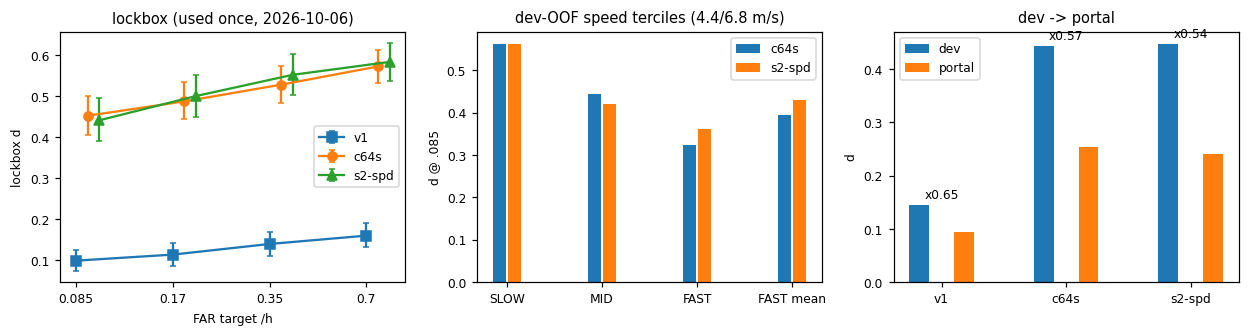

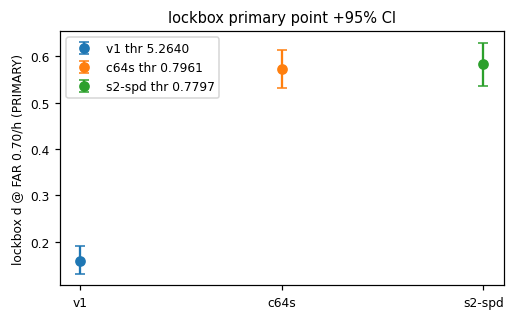

VERIFICATION SUMMARY:
  - scorer_parity_maxdiff: 1.942890293094024e-16
  - answerkey_replica_mismatches: 0
  - v1_baseline_maxdiff: 0.0
  - cache_invariants_runs: 8
  - freeze_bitexact: PASS
  - feat_target_bitexact: PASS (3 runs; lockbox feature row layout only)
  - oof_recompute_maxdiff: 0.0
  - terciles_crosscheck: PASS
  - leakguard_lines: 108
  - selection_frozen: s2-spd
  - portal_regen_md5: EQUAL both files (727 / 683 rows)
  - portal_regen_rows: (727, 683)
  - lockbox_fp_recompute: PASS (3/3)
  - lockbox_reconstruct: PASS (dev+delta == saved rows, 2e-3)
  - offdesign_probe: saved-row re-cut bit-match (uploaded-thr cut off)
notebook wall time this run: 15.7 min


In [14]:
# ---- 11.1 the three measurements (records; literals cited) ----
p2 = json.loads((SUB_DIR / "reports" / "portal2_numbers.json").read_text(encoding="utf-8"))
p3 = json.loads((LB / "third_try.json").read_text(encoding="utf-8"))
dev85 = {"c64s": float(sel_saved["c64s"][0]["0.085"]["d"]),
         "s2-spd": float(sel_saved["s2-spd"][0]["0.085"]["d"])}
dev85f = {"c64s": float(sel_saved["c64s"][0]["0.085"]["fpr"]),
          "s2-spd": dev85_far}
rows11 = [
    dict(try_="first_try", model="v1", date="2026-10-02", thr=5.7492, rows=413,
         d=0.0946, c=0.0737, id=0.0544, far=0.535, dev_ref=0.1453,
         ret=0.651, infl=2.43),
    dict(try_="second_try", model="c64s", date="2026-10-05", thr=0.8617, rows=p2["rows"],
         d=0.2530, c=0.2278, id=0.1625, far=0.0973, dev_ref=dev85["c64s"],
         ret=round(float(p2["ret"]), 4), infl=round(float(p2["infl"]), 4)),
    dict(try_="third_try", model="s2-spd", date="2026-10-06", thr=0.8536, rows=p3["rows"],
         d=float(p3["d"]), c=float(p3["c"]), id=float(p3["id"]), far=float(p3["fpr"]),
         dev_ref=dev85["s2-spd"], ret=round(float(p3["d"]) / dev85["s2-spd"], 4),
         infl=round(float(p3["fpr"]) / dev85f["s2-spd"], 4)),
]
df11 = pd.DataFrame(rows11)
print(df11.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
say(f"v1 dev_ref = official-scorer validation subset (runs 25-124) @5.7492: d .1453 far .220;")
say(f"nets dev_ref = dev-OOF 240-pool @.085 target (same thr as uploaded).")
say(f"CIs: #2 retention {float(p2['ret']):.3f} +/-{1.96*float(p2['se_ret']):.3f}, inflation "
    f"{float(p2['infl']):.2f} +/-{1.96*float(p2['se_infl_t']):.2f} | #3 retention 0.536 "
    f"[0.491,0.585], inflation 0.88 [0.50,1.26] (records)")
say(f"#3 vs #2: d {float(p3['d'])-0.2530:+.4f} (~1.1 sigma), far {float(p3['fpr'])-0.0973:+.4f} "
    f"(~1.0 sigma) -> statistically indistinguishable")
say("#3 per category (d/far):", {k: (float(v['d']), float(v['fpr']))
                                  for k, v in p3["per_category"].items()})
say("#2 per category: Global .2530/.0973 | Ind .3370/.0208 | Med .1555/.0035 | "
    "NORM .0482/.0035 | NM .2866/.0695")
say("leaderboard: our s2-spd lowest FAR among compared rows; external participants")
say("anonymized here (leaderboard.html held separately).")

# ---- 11.2 figures (small PNGs; pyplot-free Figure API - this kernel's
#      matplotlib/IPython display-hook combo breaks plt.subplots) ----
from matplotlib import rcParams as MPL_RC
from matplotlib.figure import Figure
MPL_RC.update({"font.size": 8})
fig = Figure(figsize=(11.4, 3.1), dpi=110)
axs = fig.subplots(1, 3)
tgs = [r_["target"] for r_ in res["c64s"]["rows"]]
x_ = np.arange(4)
for i, (cfg, mk) in enumerate((("v1", "s"), ("c64s", "o"), ("s2-spd", "^"))):
    dd = [float(r_["d"]) for r_ in res[cfg]["rows"]]
    lo = [float(r_["d"]) - float(r_["ci_d"][0]) for r_ in res[cfg]["rows"]]
    hi_ = [float(r_["ci_d"][1]) - float(r_["d"]) for r_ in res[cfg]["rows"]]
    axs[0].errorbar(x_ + 0.12 * i, dd, yerr=[lo, hi_], marker=mk, capsize=2, label=cfg)
axs[0].set_xticks(x_)
axs[0].set_xticklabels([f"{t:.3g}" for t in tgs])
axs[0].set_xlabel("FAR target /h"); axs[0].set_ylabel("lockbox d")
axs[0].set_title("lockbox (used once, 2026-10-06)"); axs[0].legend()
for i, cfg in enumerate(("c64s", "s2-spd")):
    tcd = sel_saved[cfg][1]["terciles"]
    axs[1].bar(x_ + (i - 0.5) * 0.16,
               [float(tcd["ter"][str(g)]["d"]["0.085"]) for g in range(3)]
               + [float(tcd["fast_mean"])], width=0.14, label=cfg)
axs[1].set_xticks(x_)
axs[1].set_xticklabels(["SLOW", "MID", "FAST", "FAST mean"])
axs[1].set_ylabel("d @ .085"); axs[1].set_title("dev-OOF speed terciles (4.4/6.8 m/s)")
axs[1].legend()
lab = ["v1", "c64s", "s2-spd"]
dv = [0.1453, dev85["c64s"], dev85["s2-spd"]]
pv = [0.0946, 0.2530, float(p3["d"])]
axs[2].bar(x_[:3] - 0.18, dv, 0.16, label="dev")
axs[2].bar(x_[:3] + 0.18, pv, 0.16, label="portal")
for i in range(3):
    axs[2].text(x_[i], max(dv[i], pv[i]) + 0.012, f"x{pv[i]/dv[i]:.2f}", ha="center")
axs[2].set_xticks(x_[:3])
axs[2].set_xticklabels(lab)
axs[2].set_ylabel("d"); axs[2].set_title("dev -> portal"); axs[2].legend()
fig.tight_layout()
f1 = OUT_DIR / "fig_summary.png"
fig.savefig(f1, bbox_inches="tight")
display(Image(filename=str(f1)))

fig2 = Figure(figsize=(5.2, 3.0), dpi=110)
ax = fig2.subplots()
for i, cfg in enumerate(("v1", "c64s", "s2-spd")):
    r70 = next(r_ for r_ in res[cfg]["rows"] if r_["target"] == 0.7)
    dd = float(r70["d"])
    ax.errorbar([i], [dd], yerr=[[dd - float(r70["ci_d"][0])],
                                 [float(r70["ci_d"][1]) - dd]],
                fmt="o", capsize=3, label=f"{cfg} thr {float(r70['thr']):.4f}")
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["v1", "c64s", "s2-spd"])
ax.set_ylabel("lockbox d @ FAR 0.70/h (PRIMARY)")
ax.set_title("lockbox primary point +95% CI")
ax.legend()
f2 = OUT_DIR / "fig_lockbox_primary.png"
fig2.savefig(f2, bbox_inches="tight")
display(Image(filename=str(f2)))

# ---- 11.3 verification checklist + runtime ----
say("VERIFICATION SUMMARY:")
for k, v in CHECKS.items():
    say(f"  - {k}: {v}")
say(f"notebook wall time this run: {(time.time()-T0)/60:.1f} min")

## 12. Атрибуция, что оригинально, ограничения, режим FULL

**Лицензия и атрибуция.** Код организаторов `radai` — BSD-3-Clause, © 2021
University of California / Lawrence Berkeley National Laboratory / Oak Ridge
National Laboratory. Таблицы `label2category` / `label2isotope` перенесены в
`submission/official_scorer.py` дословно с сохранением copyright-замечания
(допустимо лицензией); остальное официальное evaluation — зеркало с file:line
ссылками, дословного вендоринга пакета нет. Данные RADAI v4.3 — только через
BDC после регистрации; рередистрибьюшн запрещён, файлы в git отсутствуют.
Цитирование набора: «RADAI dataset (ORNL/LBNL), ML-RADAI repository».

**Что оригинально в этом проекте** (не в коде организаторов): вся v2-линейка —
guarded-восстановление answer key (`ak_window` с clip-флагом), `AlarmCurve` +
run-cluster bootstrap, заморозка сплитов/локбокса/порогов, 132-канальные
признаки с дисперсионной стабилизацией, soft-цели (гаусс вокруг win_max),
TCN-архитектура с тремя головами и focal+aux loss, synth-shift-калибровка
Step-0, аугментация speed-compression с гейтами T1/T1b/T2/G1–G3, схема-(a)
генерация CSV, целочисленный fit портальных метрик (N_enc), power-анализ
локбокса. v1 matched filter — исходный этап (архивный `Matched_Filter_Detection.ipynb`).

**Ограничения (честно).** (1) dev→portal удержание d ≈0.54–0.57: остаточный
сдвиг распределений между training-пулом и testing не смоделирован полностью;
прямое тому свидетельство — контроль §10.3/§10.4: на seal-пуле при закреплённых
dev-порогах те же модели дают d≈0.43–0.44 (как на dev), а опубликованные
портальные замеры при тех же frozen CSV — 0.24–0.25: testing-порог уехал в хвост
распределения. (Отсечка seal-пуля на uploaded-порогах печатается только при
явном `LOCKBOX_RECOMPUTE=True` — протокол «использовано один раз».)
(2) Seed-шум: нижняя граница различимости конфигов NF 0.025–0.061 по d —
приращения меньше неё не значимы: s2-spd vs c64s dev +0.005…+0.011 (CI∋0),
локбокс +0.011 [−0.030,+0.050], портал −0.013 (~1.1σ) — **выигрыш аугментации
на сдвиге не доказан** (в within-CI смысле; «не стало хуже» — да).
(3) Локбокс использован один раз — пересмотра нет; лимит портала 5 замеров,
3 потрачено. (4) N_enc testing 2756 vs 2763 (фиты #3/#2) — 7-встречное
расхождение, раскрыто. (5) NORM d≈0.005–0.05 у всех моделей — слабые
K-40/U/Th-встречи детектируются плохо; id-головка в Medical теряется на редких
изотопах. (6) Портал не даёт per-run детерминации — все «портал-числа»
восстановлены целочисленным фитом с явными CI.

**Режимы.** В `FULL` ноутбук пересобирает 1-с кэши (§4, по явному flag-guard) и
ничего не обучает: обучение — внешние скрипты `s1_run.py` (часы), чтобы
опубликованные и перегенерированные веса не смешивались. Локбокс-скоринг
seal-прогонов не запускается ни в каком режиме (§10 загружает результат).

**Верификации этого ноутбука** (полные следы — в `CLEANUP_PLAN.md` §4):
1. полный прогон ячейка-за-ячейкой (nbclient, время печатается в §11.3);
2. v1-таблицы == `reports/v1_baseline.json`, max|diff| = 0 (§3);
3. OOF c64s/s2-spd == сохранённые метрики, max|diff| = 0 (§7);
4. перегенерированные портал-CSV байт-в-байт == загруженные md5 (§9);
5. ни личных путей, ни имён участников в тексте/выводах (§0 helpers + аудит);
6. размер ноутбука < 5 МБ, выводы — таблицы и два PNG.